# Lab 7 - Ruido

## Ejercicio 1.

Considere una neurona LIF sujeta a ruido blanco con valores de intensidad $\sigma = [1, 2, 3]$. Para cada valor simule la neurona hasta que genere por lo menos 1000 spikes.

1. Muestre en cada caso el gráfico del potencial de membrana en el tiempo en una ventana de tiempo corta
2. Calcule la distribución del ISI
3. Calcule la ACF del tren de spikes emitido
4. Calcule el espectro de potencia del tren de spikes.

Use el método de Euler Maruyama con $dt = 0.1$, use para el ejercicio los siguientes parámetros.

- $R = 1$, $I_{det} = 10$, $V_{rest}=V_{reset}=-65mV$, $V_{th} = -50mV$, $\tau_m = 10$



### LIF con Euler - Maruyama

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, welch

def lif(sigma=1 # Amplitud del ruido
):
    # ---- Parámetros de la neurona LIF ----
    R = 1                  # Resistencia
    I_det = 10             # Corriente determinista
    V_rest = V_reset = -65 # Potencial de reposo y reset
    V_th = -50             # Umbral de disparo
    tau_m = 10             # Constante de tiempo de membrana (ms)
    dt = 0.1               # Paso de tiempo
    spikes_target = 1000   # Número de spikes a simular

    # ---- Solución con Euler - Maruyama ----

    V = V_reset
    t = 0

    voltages = []
    times = []
    spike_times = []

    while len(spike_times) < spikes_target:
        # Ruido blanco gaussiano
        dW = np.random.normal(0, np.sqrt(dt)) # Incremento de Wiener, Genera un valor aleatorio con media 0 y desviación estándar sqrt(dt)

        # Ecuación LIF con ruido (Euler-Maruyama)
        dV_dt = (-(V - V_rest) + R * I_det) / tau_m
        V += dV_dt * dt + sigma * dW

        if V >= V_th:
            spike_times.append(t)
            V = V_reset

        voltages.append(V)
        times.append(t)

        t += dt

    # ---- Gráficas del potencial de membrana ----

    plt.figure(figsize=(10, 4))
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana completo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana en 1 segundo")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.scatter(spike_times, [V_th]*len(spike_times), color='r', s=20, zorder=3, label='spikes')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Histogramas de ISI ----

    isis = np.diff(spike_times)
    bins = 200                # Número de barras para los histogramas
    isi_mean = np.mean(isis)
    burst_isi_thresh = 0.1    # Umbral para separar ISI rápidos y lentos (s)
    isi_fast = isis[isis < burst_isi_thresh]
    isi_low = isis[isis >= burst_isi_thresh]

    plt.figure(figsize=(10,4))
    plt.hist(isis, bins=bins, color='C0', edgecolor='k', alpha=0.9)
    plt.axvline(isi_mean, color='r', linestyle='--', label=f"mean={isi_mean:.1f} ms")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.title("Histograma de ISI")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- histograma isi rápido ---
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(isi_fast, bins=bins, color='C0', edgecolor='k')
    if len(isi_fast) > 0:
        plt.axvline(np.mean(isi_fast), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_fast):.1f} ms")
    plt.title("ISI rápido")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)

    # --- histograma isi lento ---
    plt.subplot(1,2,2)
    plt.hist(isi_low, bins=bins, color='C1', edgecolor='k')
    if len(isi_low) > 0:
        plt.axvline(np.mean(isi_low), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_low):.1f} ms")
    plt.title("ISI lento")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Autocorrelación (ACF) ---
    dt_bin = 2.0  # ms (2.0 ms bins)
    duration = times[-1] - times[0]
    N_bins = int(np.ceil(duration / dt_bin))
    spike_train = np.zeros(N_bins)

    for spike_time in spike_times:
        bin_idx = int((spike_time - times[0])/ dt_bin)
        if 0 <= bin_idx < N_bins:
            spike_train[bin_idx] = 1

    bin_centers = np.arange(N_bins) * dt_bin + dt_bin / 2.0

    correlate_complete = fftconvolve(spike_train, spike_train[::-1], mode='full') # fftconvolve es más eficiente
    correlate_positive = correlate_complete[len(correlate_complete)//2:]  # Tomar solo la mitad positiva
    correlate_positive = correlate_positive / correlate_positive[0] # Normalizar

    # Crear eje de tiempo para autocorrelación
    t_correlate_complete = np.arange(len(correlate_complete)) * dt_bin
    t_correlate_positive = np.arange(len(correlate_positive)) * dt_bin

    # Función de autocorrelación completa
    plt.figure(figsize=(10, 4))
    plt.plot(t_correlate_complete, correlate_complete, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación completa')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Función de autocorrelación positiva
    plt.figure(figsize=(10, 4))
    plt.plot(t_correlate_positive, correlate_positive, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación normalizada (lado positivo)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Trenes de spikes
    plt.figure(figsize=(10,4))
    plt.subplot(3,1,1)
    plt.plot(bin_centers, spike_train, drawstyle='steps-mid', color='k')
    plt.ylim(-0.1, 1.1)
    plt.xlabel('tiempo (ms)')
    plt.ylabel('spike (0/1)')
    plt.title(f'tren de spikes (Δt = 2.0 ms)')
    plt.show()

    # ---- Densidad espectral de potencia (welch) ----
    fs_bin = 1000.0 / dt_bin
    frequencies_welch, power_spectrum = welch(spike_train, fs=fs_bin, nperseg=min(256, len(spike_train)//4))

    # ---- Densidad espectral de potencia (psd) ----
    fft_result = np.fft.rfft(spike_train)
    frequencies_psd = np.fft.rfftfreq(len(spike_train), d=0.02)
    psd = np.abs(fft_result)**2 / (len(spike_train) * 0.02)

    # Densidad espectral de potencia (Welch)
    plt.figure(figsize=(10, 4))
    plt.semilogy(frequencies_welch, power_spectrum, color='C1')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (Welch)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Densidad espectral de potencia (PSD)
    plt.figure(figsize=(10, 4))
    plt.semilogy(frequencies_psd, psd, color='C2')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (PSD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Resultados con sigma=1

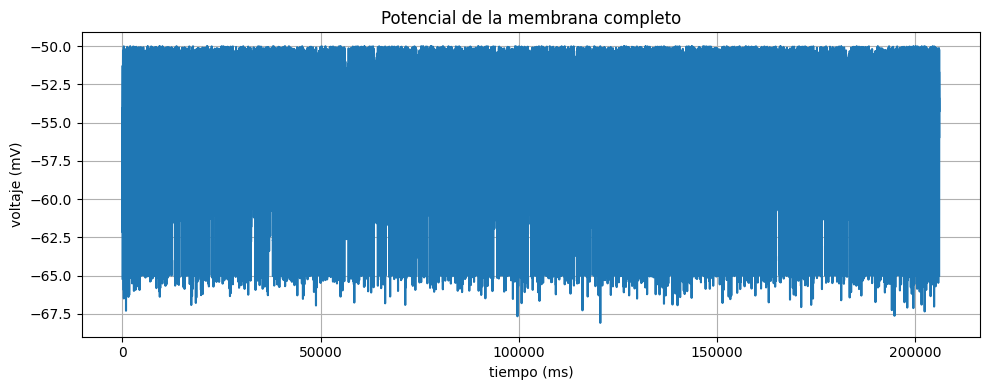

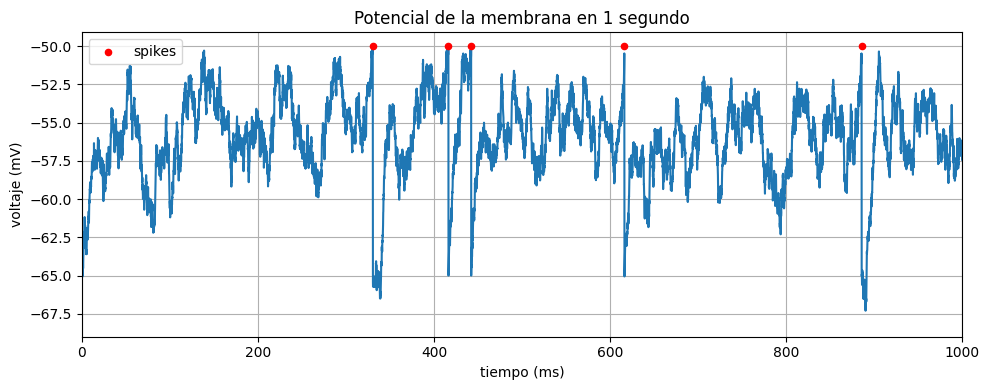

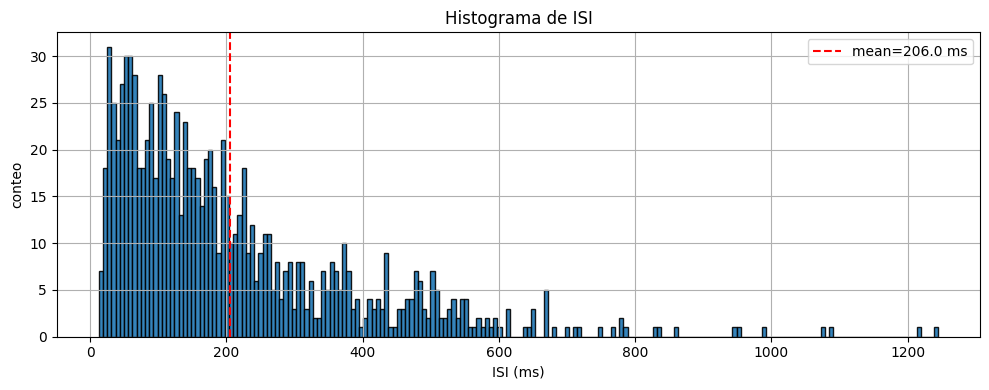

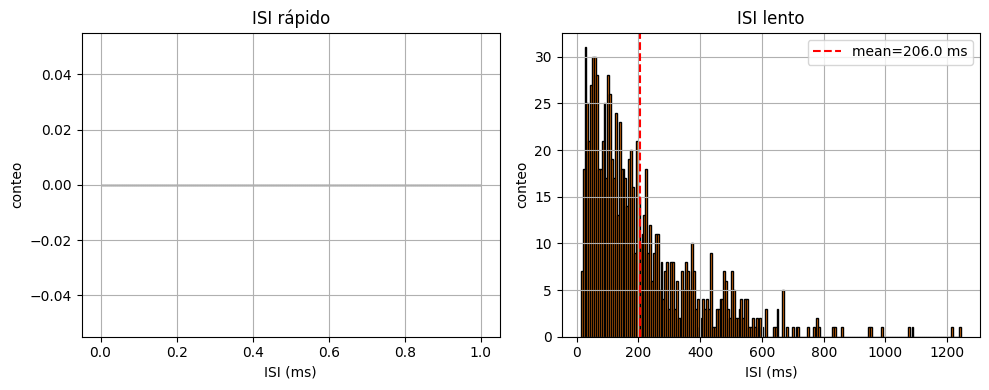

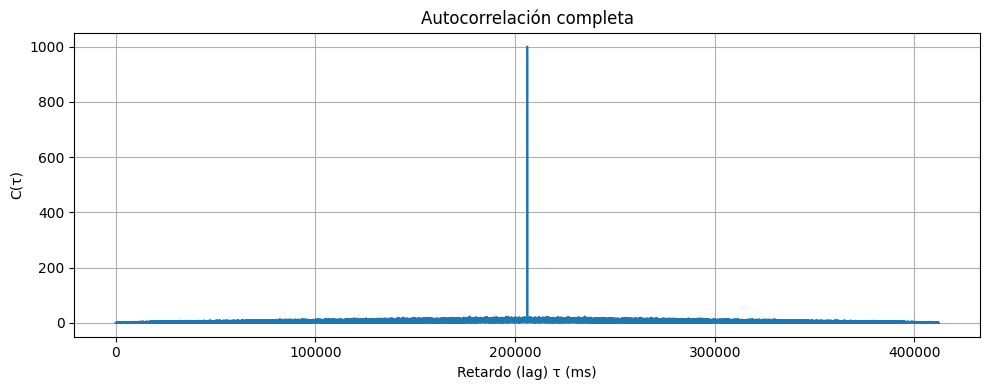

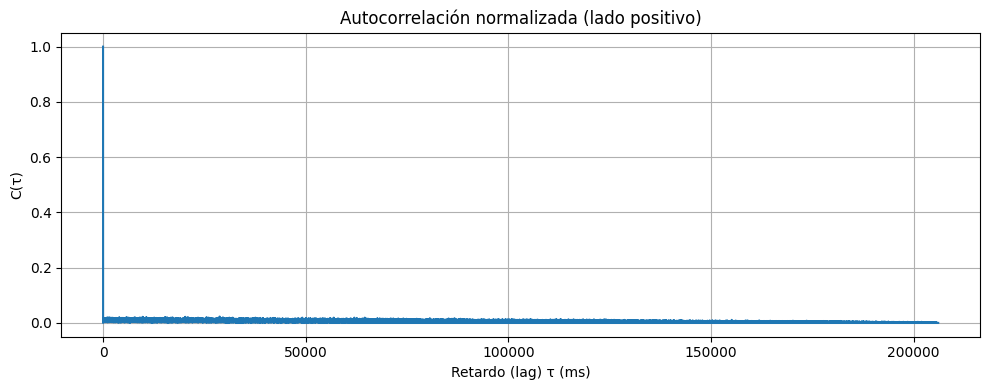

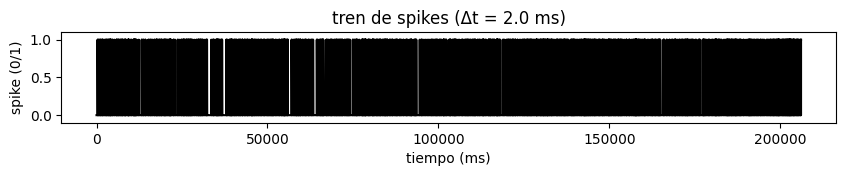

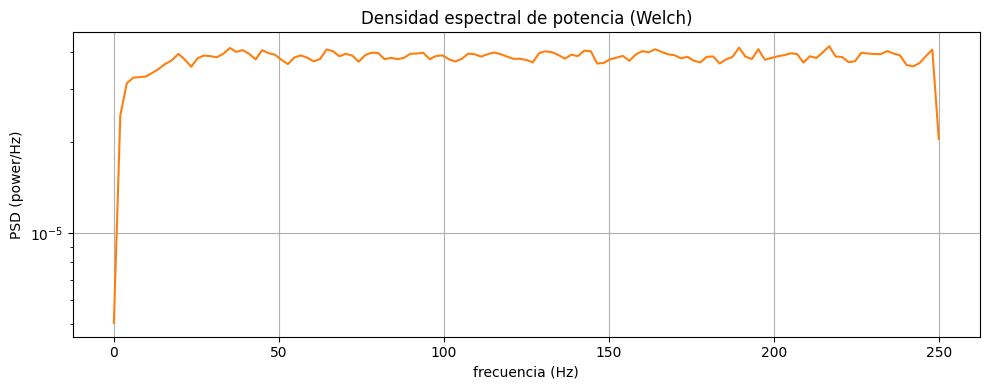

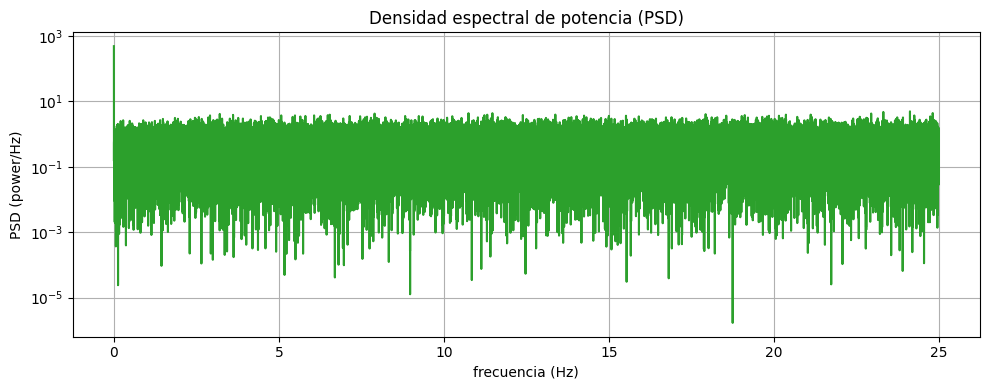

In [88]:
lif(sigma=1)

### Resultados con sigma=2

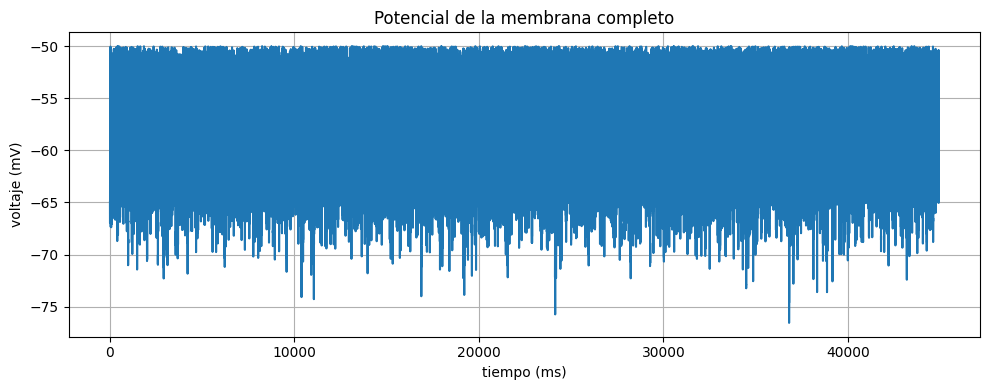

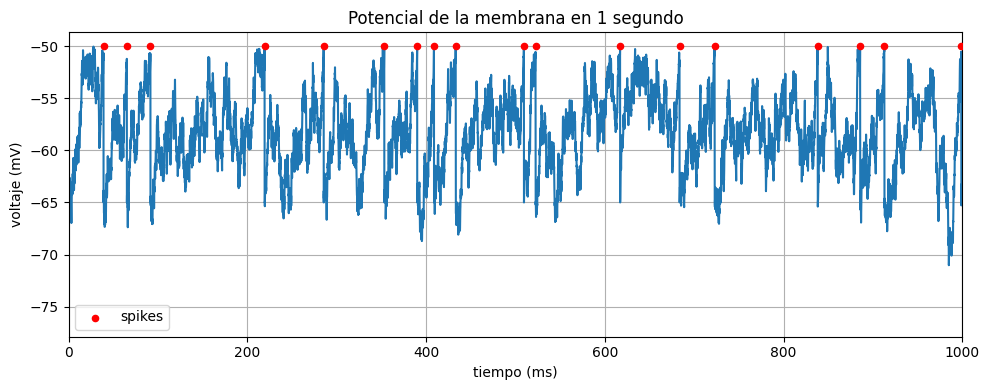

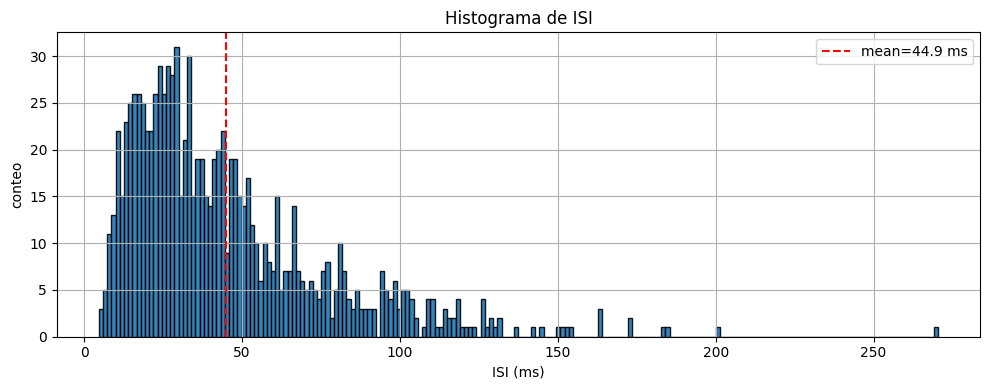

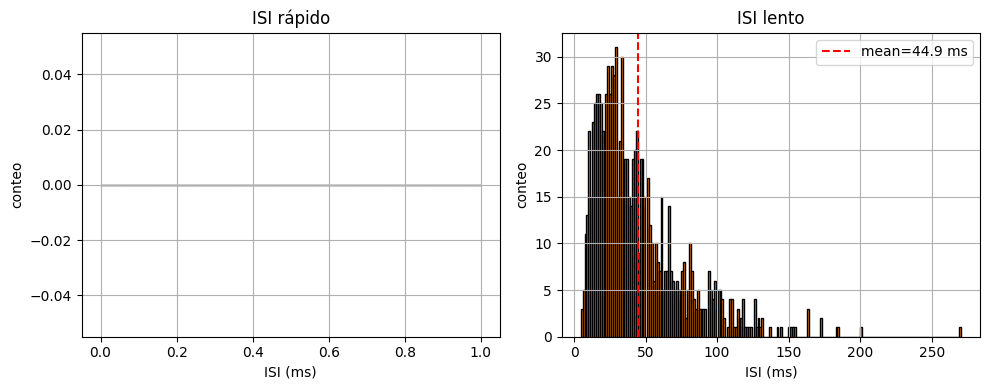

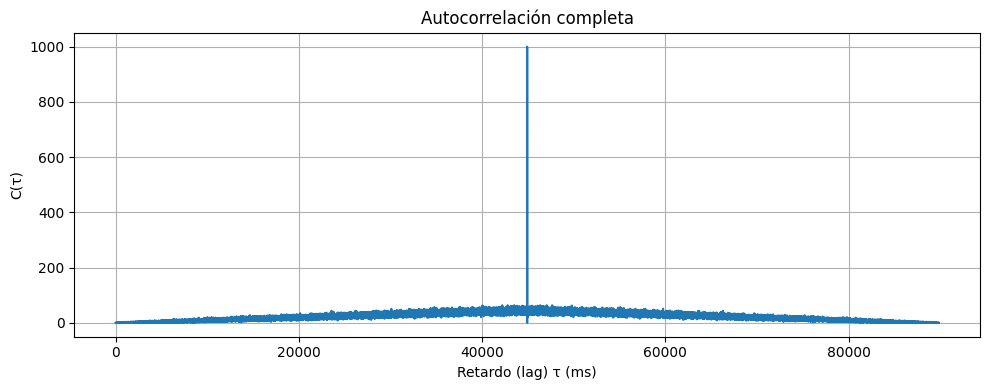

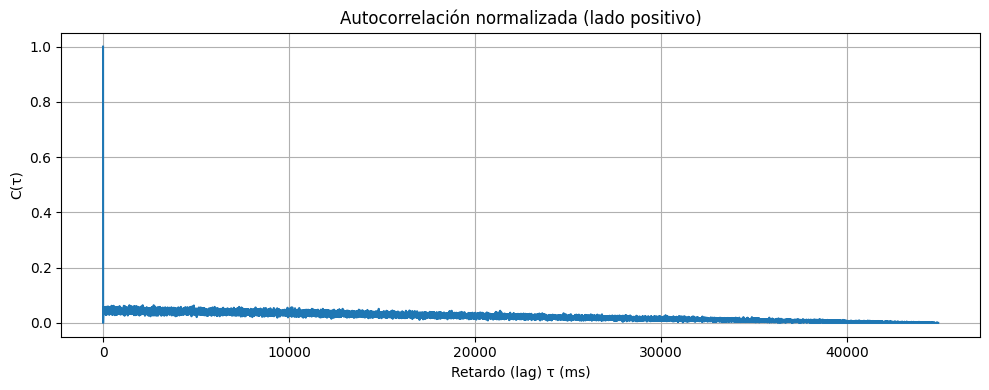

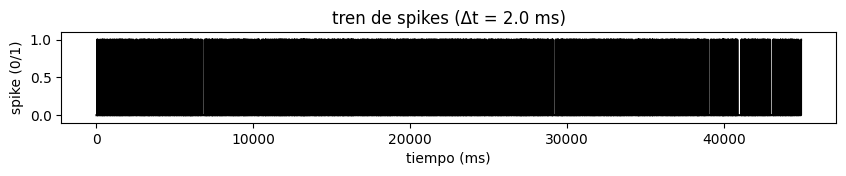

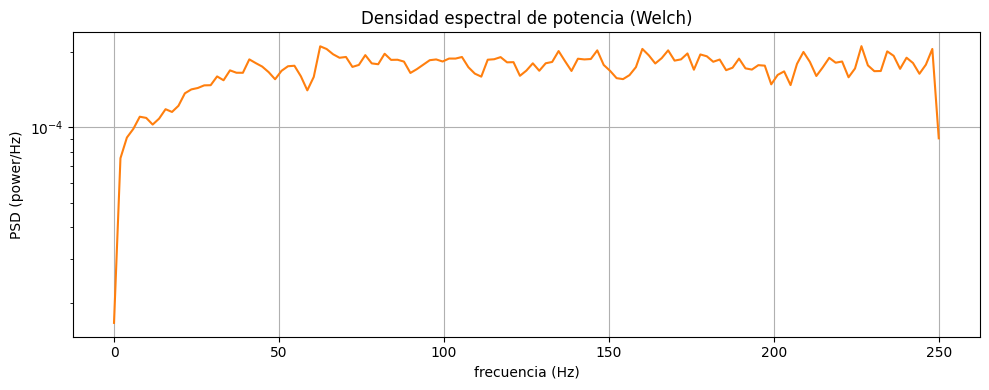

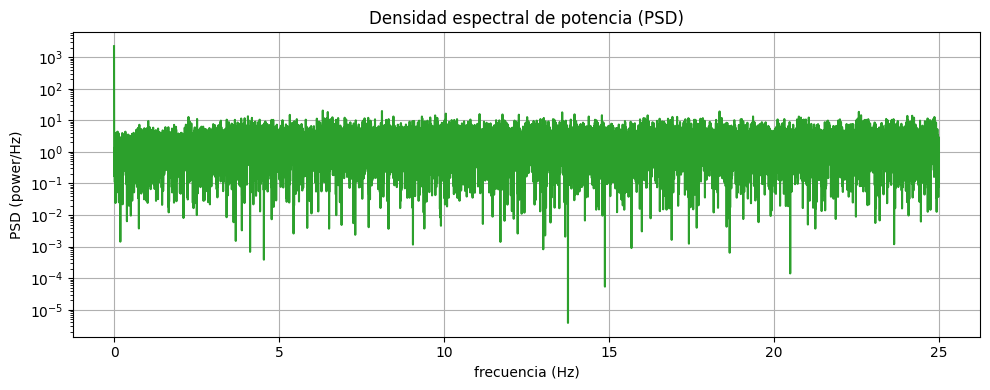

In [77]:
lif(sigma=2)

### Resultados con sigma=3

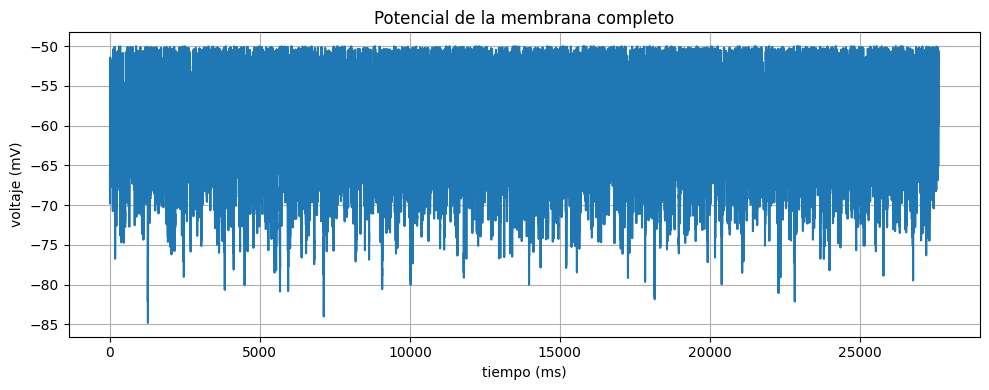

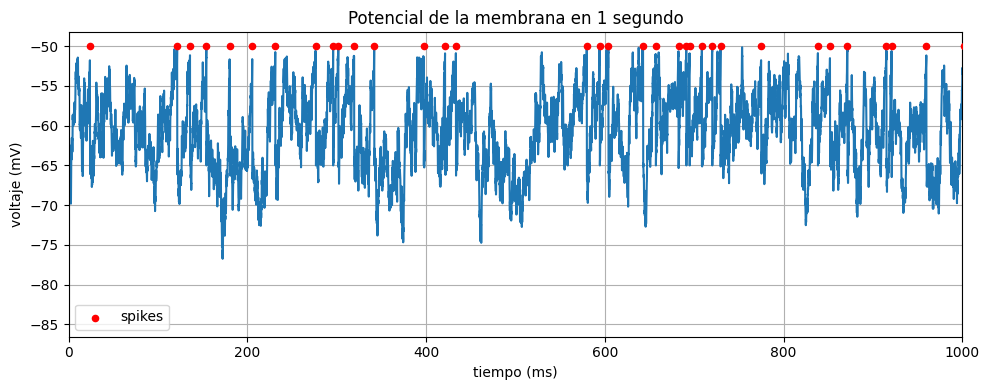

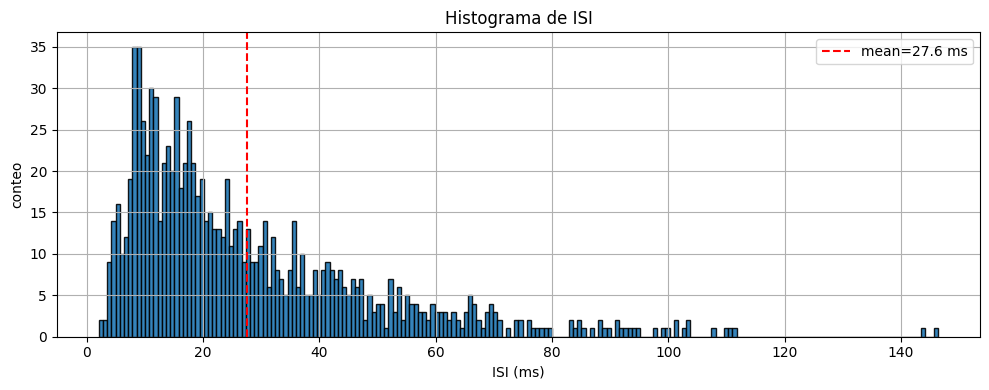

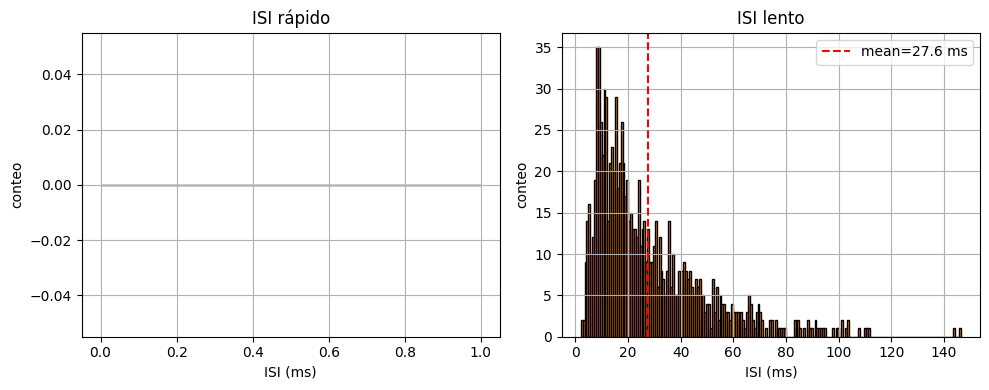

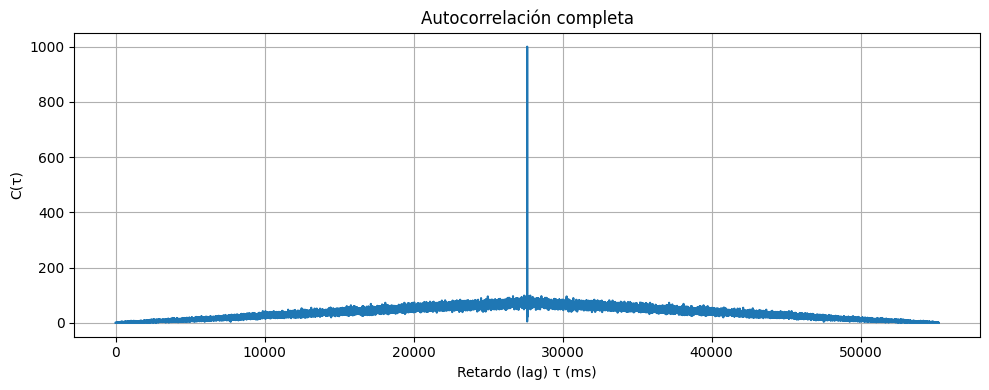

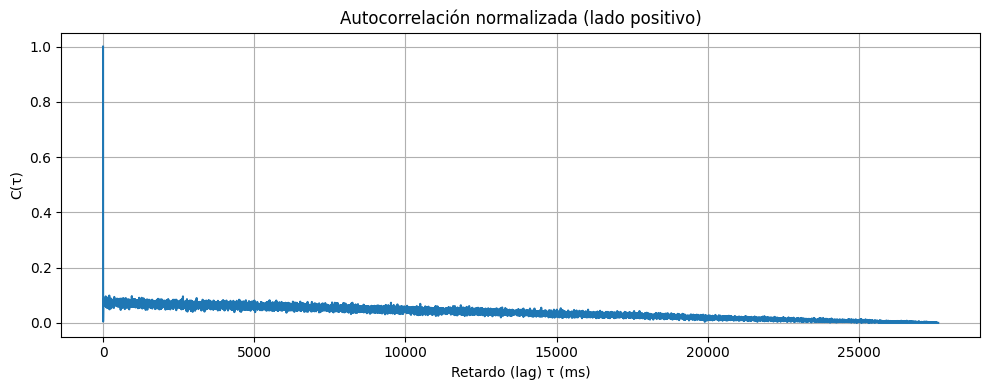

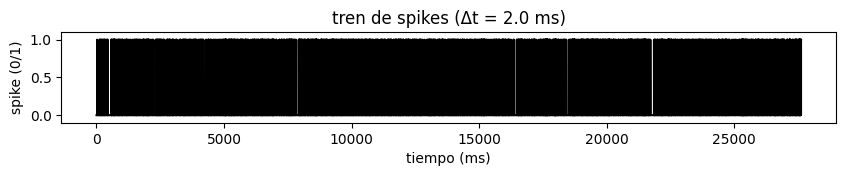

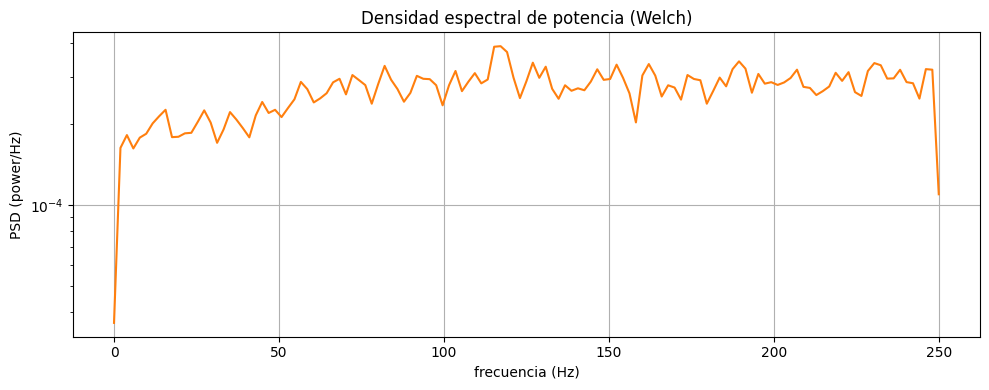

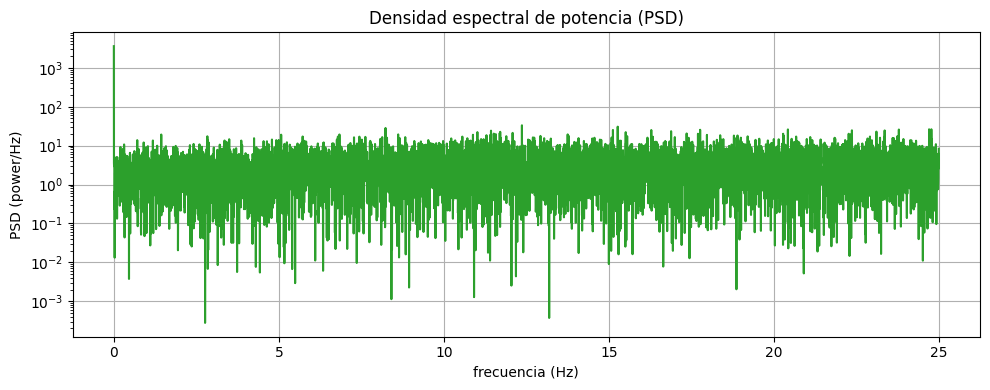

In [78]:
lif(sigma=3)

## Ejercicio 2.

Con los mismos parámetros anteriores repita el ejercicio 1 pero ahora suponga que el ruido es de color y éste es producido a su vez por un proceso de Ornstein-Ulhenbeck con tiempo de correlación $\tau_s = 20ms$.

1. Muestre la función de autocorrelación y el espectro de la corriente $I_{noise}(t)$ en cada caso
2. Muestre las mismas gráficas del ejercicio 2 y discuta las diferencias

### Solución LIF con ruido de color (Orstein-Ulgenbeck)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve, welch

def lif_noise(sigma=1 # Amplitud del ruido
):
    # ---- Parámetros de la neurona LIF ----
    R = 1                  # Resistencia
    I_det = 10             # Corriente determinista
    V_rest = V_reset = -65 # Potencial de reposo y reset
    V_th = -50             # Umbral de disparo
    tau_m = 10             # Constante de tiempo de membrana (ms)
    dt = 0.1               # Paso de tiempo
    spikes_target = 1000   # Número de spikes a simular
    I_noise = 0.0          # Corriente de ruido
    tau_s = 20.0           # Constante de tiempo del ruido (ms)

    # ---- Solución con Euler - Maruyama ----

    V = V_reset
    t = 0

    voltages = []
    times = []
    spike_times = []
    noise_values = []

    while len(spike_times) < spikes_target:
        # Ruido blanco gaussiano
        dW = np.random.normal(0, np.sqrt(dt)) # Incremento de Wiener, Genera un valor aleatorio con media 0 y desviación estándar sqrt(dt)
        I_noise += (-I_noise / tau_s) * dt + np.sqrt(2 * sigma**2 / tau_s) * dW
        noise_values.append(I_noise)

        # Ecuación LIF con ruido (Euler-Maruyama)
        I_total = I_det + I_noise
        dV_dt = (-(V - V_rest) + R * I_total) / tau_m
        V += dV_dt * dt + sigma * dW

        if V >= V_th:
            spike_times.append(t)
            V = V_reset

        voltages.append(V)
        times.append(t)

        t += dt

    # ---- Gráficas del potencial de membrana ----

    plt.figure(figsize=(10, 4))
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana completo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana en 1 segundo")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.scatter(spike_times, [V_th]*len(spike_times), color='r', s=20, zorder=3, label='spikes')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Histogramas de ISI ----

    isis = np.diff(spike_times)
    bins = 200                # Número de barras para los histogramas
    isi_mean = np.mean(isis)
    burst_isi_thresh = 0.1    # Umbral para separar ISI rápidos y lentos (s)
    isi_fast = isis[isis < burst_isi_thresh]
    isi_low = isis[isis >= burst_isi_thresh]

    plt.figure(figsize=(10,4))
    plt.hist(isis, bins=bins, color='C0', edgecolor='k', alpha=0.9)
    plt.axvline(isi_mean, color='r', linestyle='--', label=f"mean={isi_mean:.1f} ms")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.title("Histograma de ISI")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- histograma isi rápido ---
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.hist(isi_fast, bins=bins, color='C0', edgecolor='k')
    if len(isi_fast) > 0:
        plt.axvline(np.mean(isi_fast), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_fast):.1f} ms")
    plt.title("ISI rápido")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)

    # --- histograma isi lento ---
    plt.subplot(1,2,2)
    plt.hist(isi_low, bins=bins, color='C1', edgecolor='k')
    if len(isi_low) > 0:
        plt.axvline(np.mean(isi_low), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_low):.1f} ms")
    plt.title("ISI lento")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Autocorrelación (ACF) ---
    dt_bin = 2.0  # ms (2.0 ms bins)
    duration = times[-1] - times[0]
    N_bins = int(np.ceil(duration / dt_bin))
    spike_train = np.zeros(N_bins)

    for spike_time in spike_times:
        bin_idx = int((spike_time - times[0])/ dt_bin)
        if 0 <= bin_idx < N_bins:
            spike_train[bin_idx] = 1

    bin_centers = np.arange(N_bins) * dt_bin + dt_bin / 2.0

    correlate_complete = fftconvolve(spike_train, spike_train[::-1], mode='full') # fftconvolve es más eficiente
    correlate_positive = correlate_complete[len(correlate_complete)//2:]  # Tomar solo la mitad positiva
    correlate_positive = correlate_positive / correlate_positive[0] # Normalizar

    # Crear eje de tiempo para autocorrelación
    t_correlate_complete = np.arange(len(correlate_complete)) * dt_bin
    t_correlate_positive = np.arange(len(correlate_positive)) * dt_bin

    # Función de autocorrelación completa
    plt.figure(figsize=(10, 4))
    plt.plot(t_correlate_complete, correlate_complete, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación completa')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Función de autocorrelación positiva
    plt.figure(figsize=(10, 4))
    plt.plot(t_correlate_positive, correlate_positive, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación normalizada (lado positivo)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Autocorrelación Orstein-Uhlenbeck ----

    noise = np.array(noise_values)
    acf_noise = fftconvolve(noise, noise[::-1], mode='full')
    acf_noise = acf_noise[len(acf_noise)//2:]
    acf_noise_positive = acf_noise/acf_noise[0]

    # Crear eje de tiempo para autocorrelación
    t_acf_noise = np.arange(len(acf_noise)) * dt
    t_acf_noise_positive = np.arange(len(acf_noise_positive)) * dt

    # Función de autocorrelación de la corriente de ruido
    plt.figure(figsize=(10, 4))
    plt.plot(t_acf_noise, acf_noise, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación de la corriente de ruido (completa)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Función de autocorrelación de la corriente de ruido (positiva)
    plt.figure(figsize=(10, 4))
    plt.plot(t_acf_noise_positive, acf_noise_positive,color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación  de la corriente de ruido normalizada (lado positivo)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Trenes de spikes
    plt.figure(figsize=(10,4))
    plt.subplot(3,1,1)
    plt.plot(bin_centers, spike_train, drawstyle='steps-mid', color='k')
    plt.ylim(-0.1, 1.1)
    plt.xlabel('tiempo (ms)')
    plt.ylabel('spike (0/1)')
    plt.title(f'tren de spikes (Δt = 2.0 ms)')
    plt.show()

    # ---- Densidad espectral de potencia (welch) ----
    fs_bin = 1000.0 / dt_bin
    frequencies_welch, power_spectrum = welch(spike_train, fs=fs_bin, nperseg=min(256, len(spike_train)//4))

    # ---- Densidad espectral de potencia (psd) ----
    fft_result = np.fft.rfft(spike_train)
    frequencies_psd = np.fft.rfftfreq(len(spike_train), d=0.02)
    psd = np.abs(fft_result)**2 / (len(spike_train) * 0.02)

    # Densidad espectral de potencia (Welch)
    plt.figure(figsize=(10, 4))
    plt.semilogy(frequencies_welch, power_spectrum, color='C1')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (Welch)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Densidad espectral de potencia (PSD)
    plt.figure(figsize=(10, 4))
    plt.semilogy(frequencies_psd, psd, color='C2')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (PSD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Densidad espectral de potencia de la corriente de ruido de color (welch) ----
    fs_bin = 1000.0 / dt_bin
    noise_frequencies_welch, noises_power_spectrum = welch(noise, fs=fs_bin, nperseg=min(256, len(noise)//4))

    # ---- Densidad espectral de potencia de la corriente de ruido de color (psd) ----
    noise_fft_result = np.fft.rfft(noise)
    noise_frequencies_psd = np.fft.rfftfreq(len(noise), d=0.02)
    noise_psd = np.abs(noise_fft_result)**2 / (len(noise) * 0.02)

    # Densidad espectral de corriente de ruido (Welch)
    plt.figure(figsize=(10, 4))
    plt.semilogy(noise_frequencies_welch, noises_power_spectrum, color='C1')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de la corriente de ruido (Welch)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Densidad espectral de corriente de ruido (PSD)
    plt.figure(figsize=(10, 4))
    plt.semilogy(noise_frequencies_psd, noise_psd, color='C2')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de la corriente de ruido (PSD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Resultados de ruido de color con sigma=1

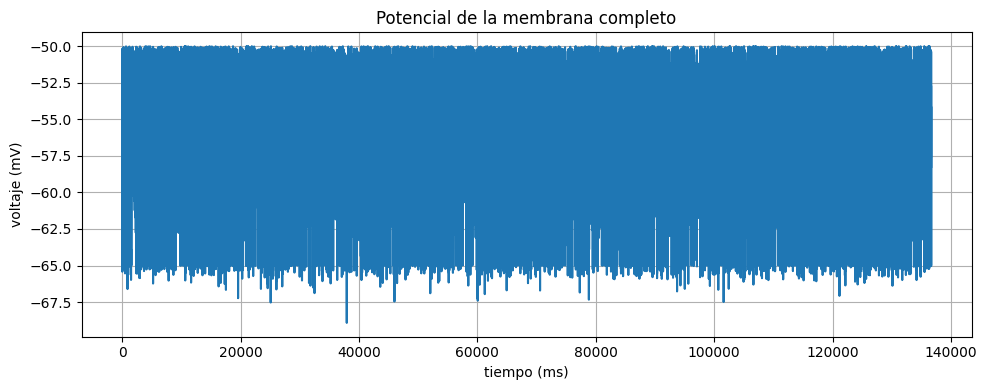

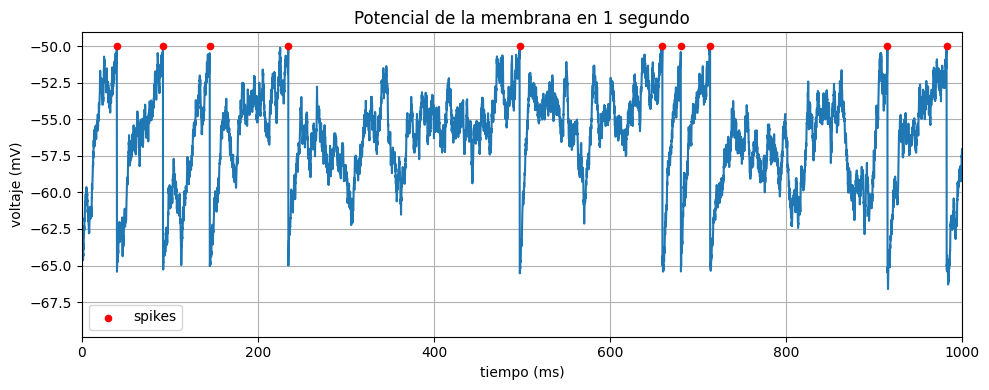

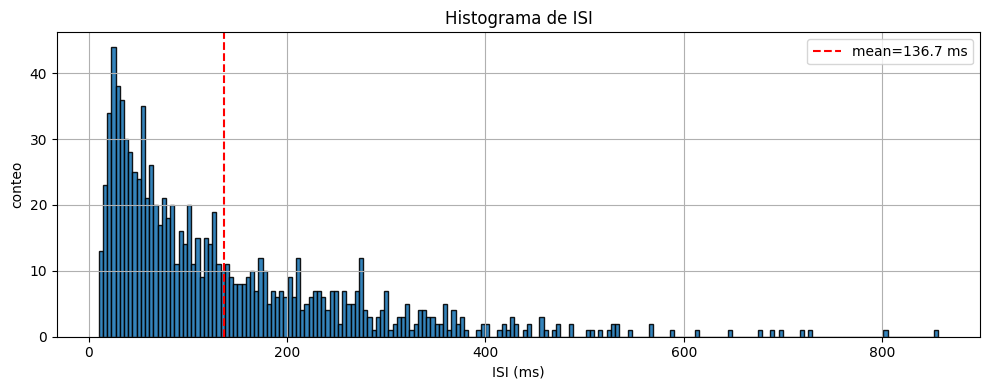

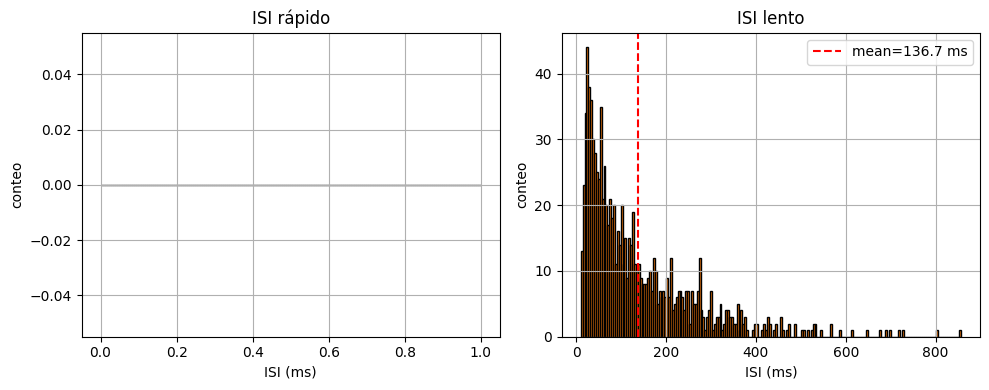

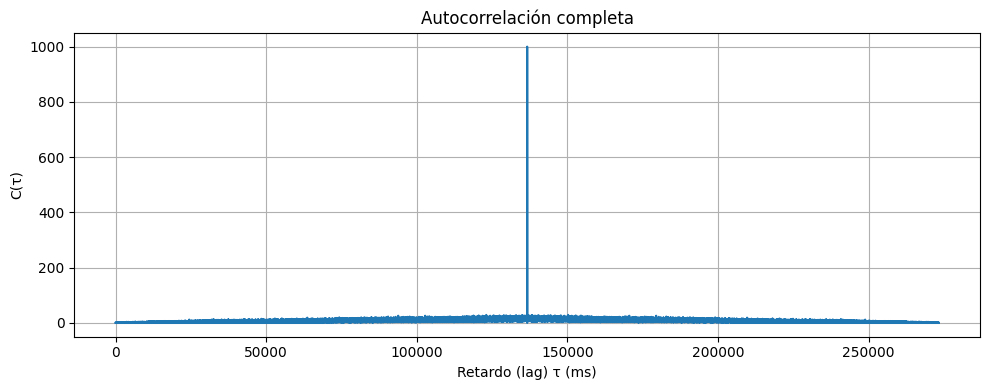

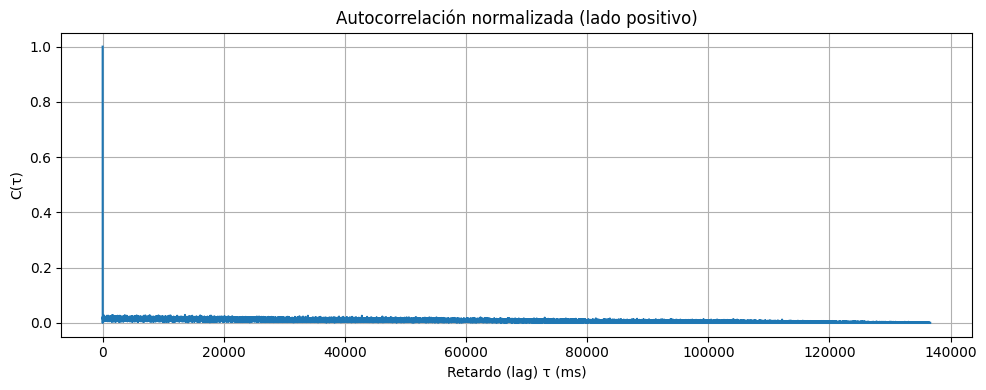

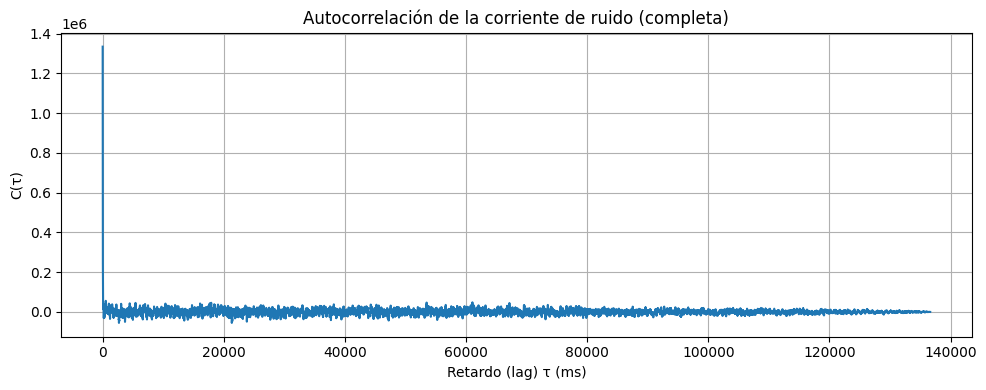

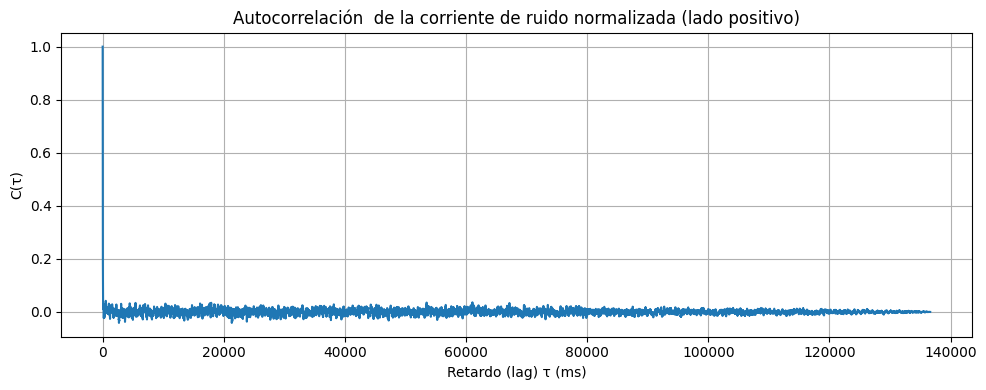

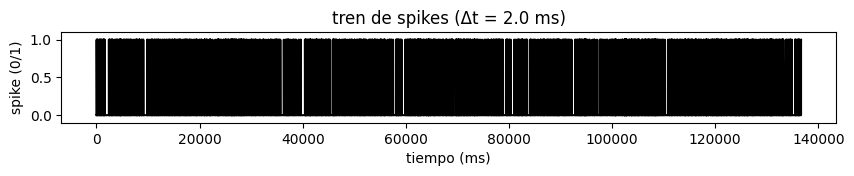

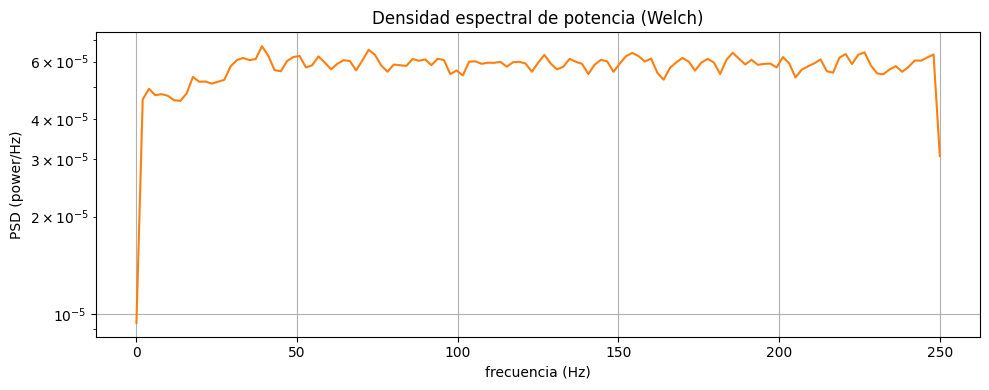

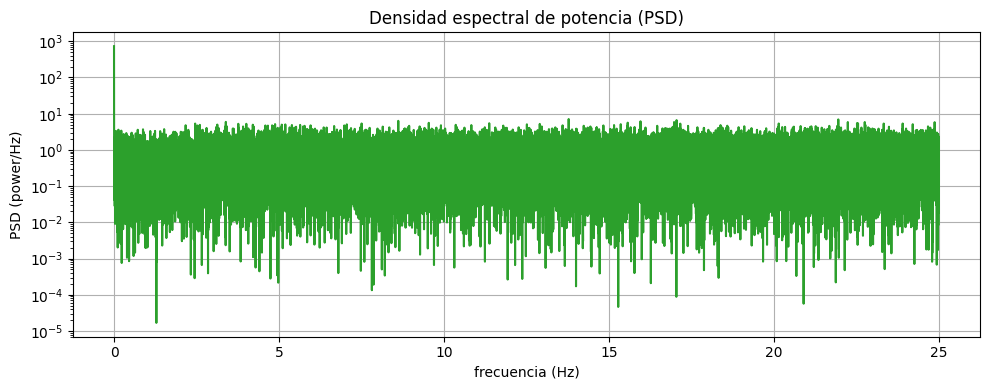

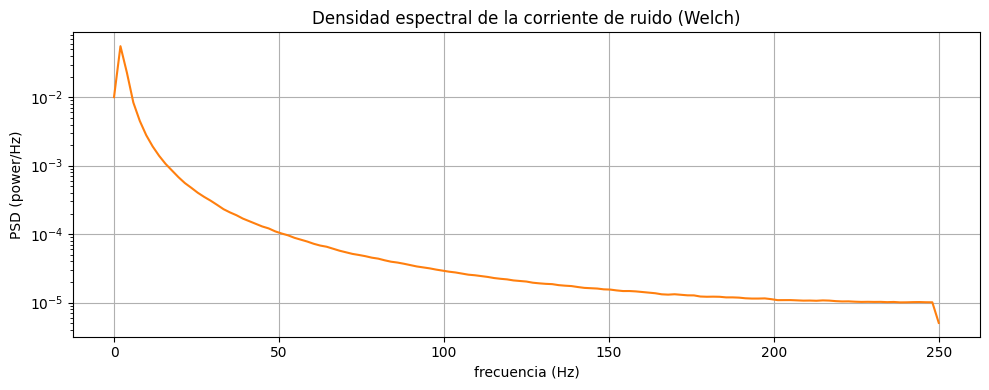

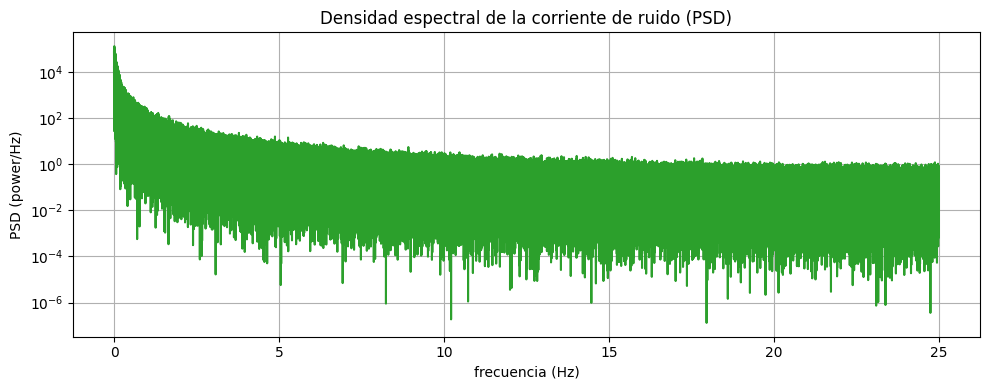

In [80]:
lif_noise(sigma=1)

### Resultados de ruido de color con sigma=2

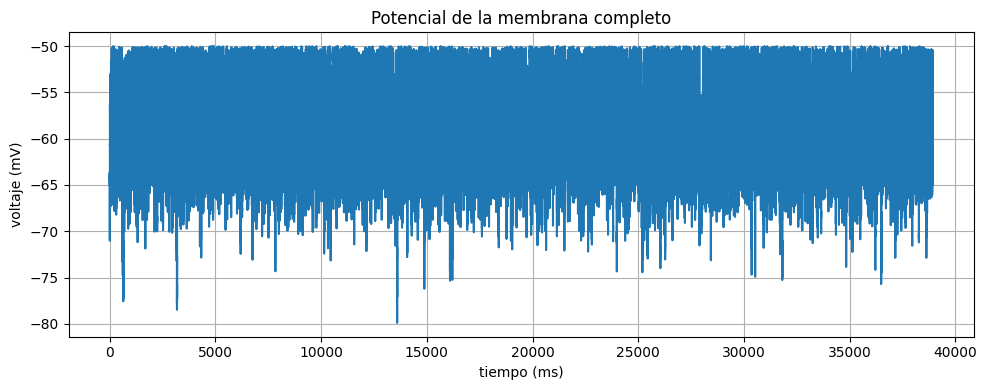

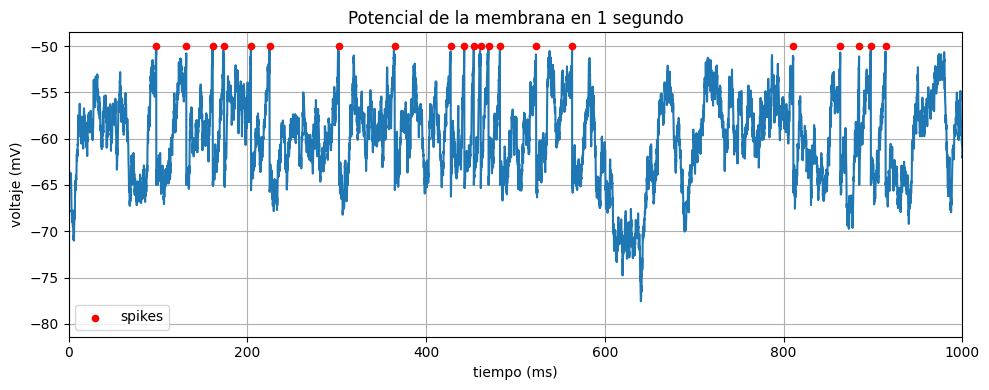

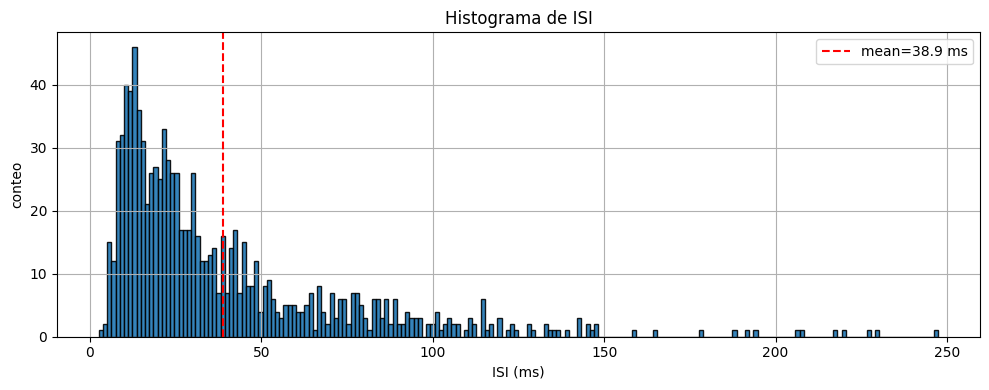

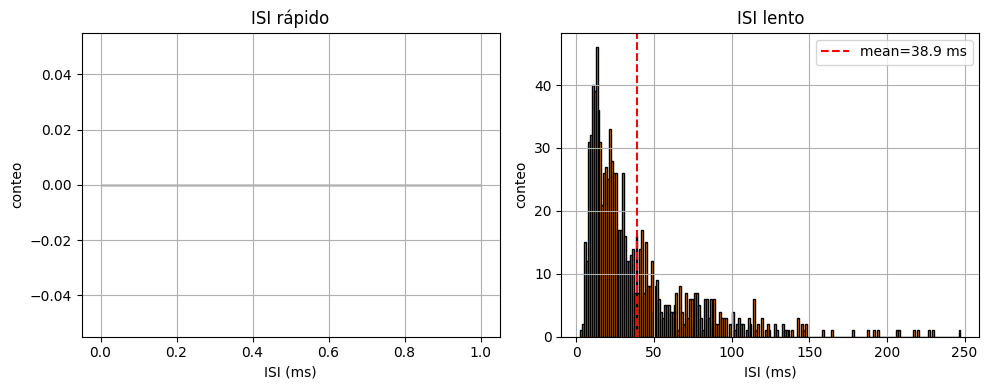

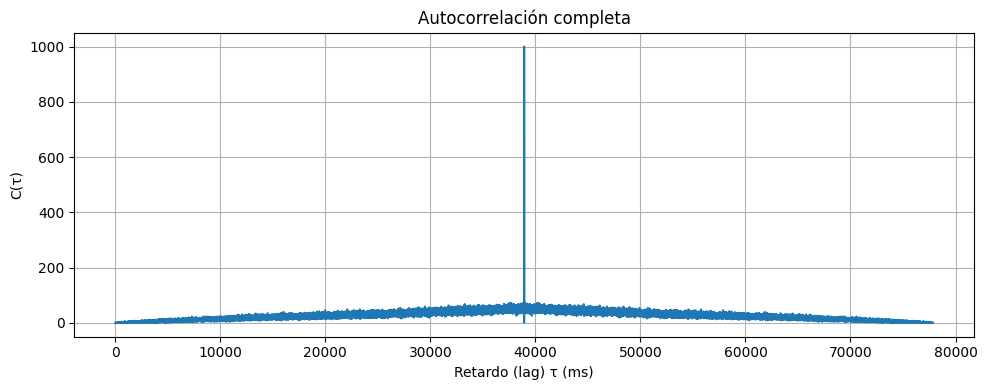

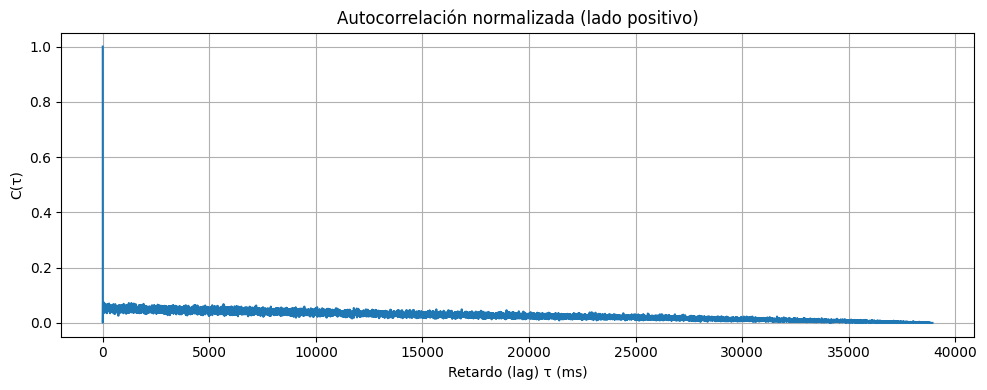

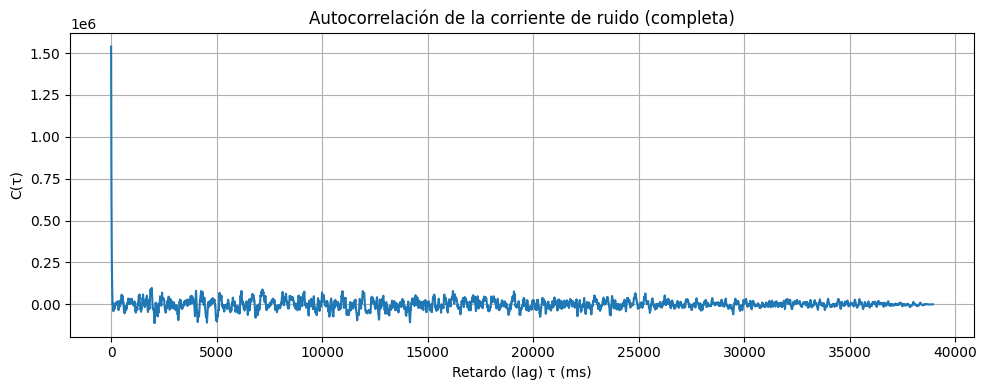

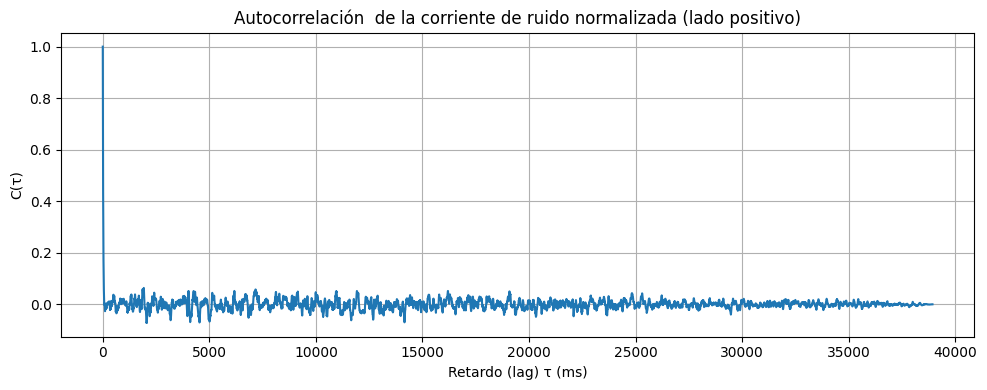

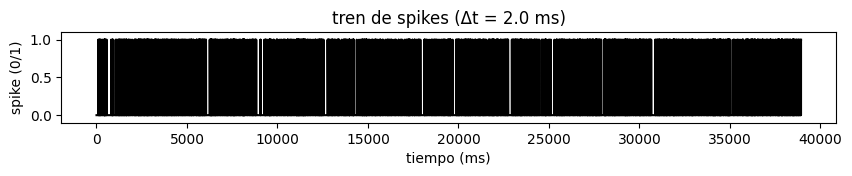

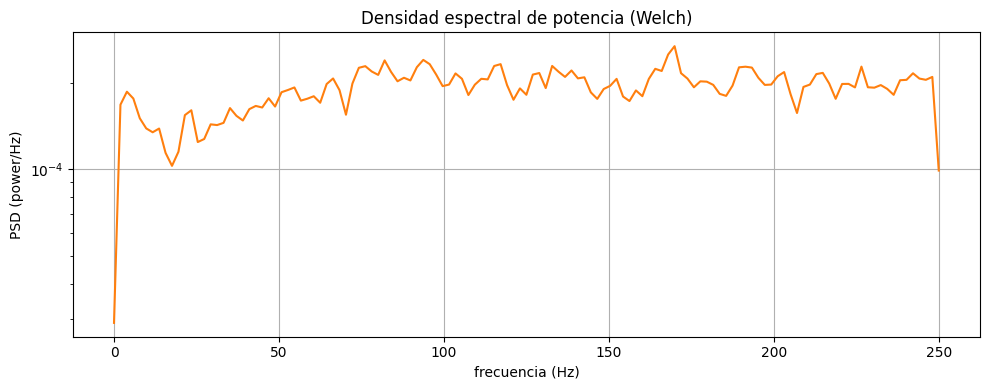

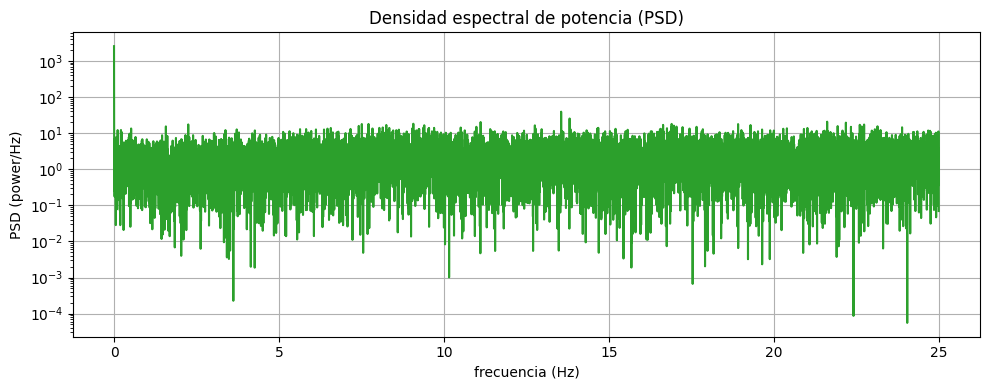

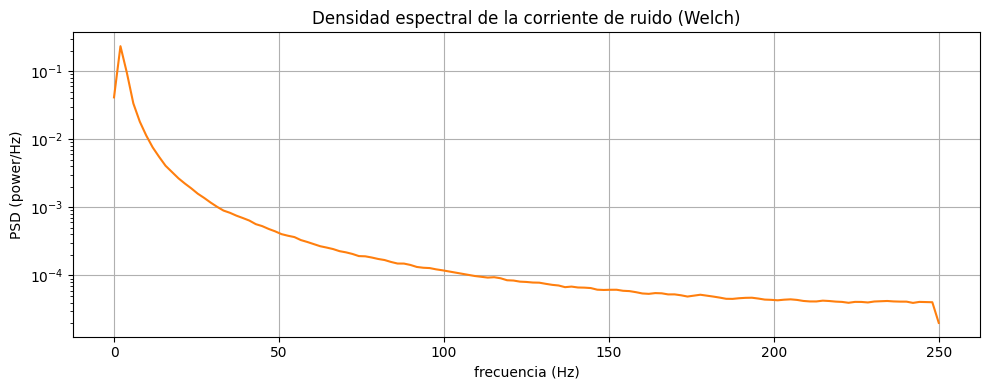

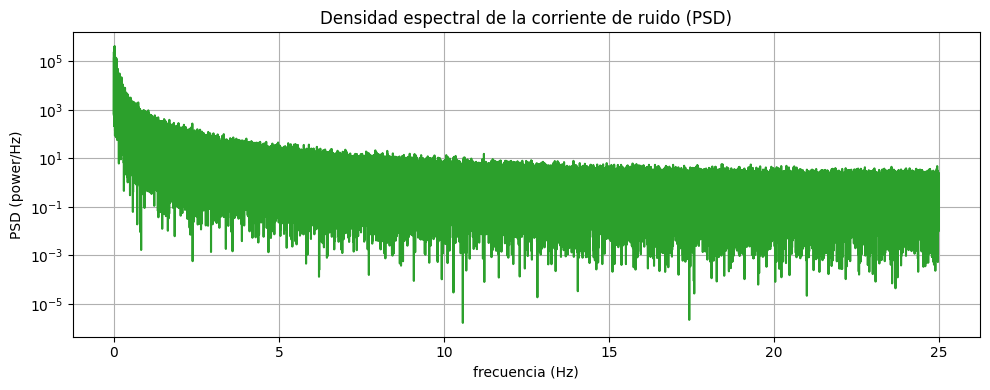

In [81]:
lif_noise(sigma=2)

### Resultados de ruido de color con sigma=3

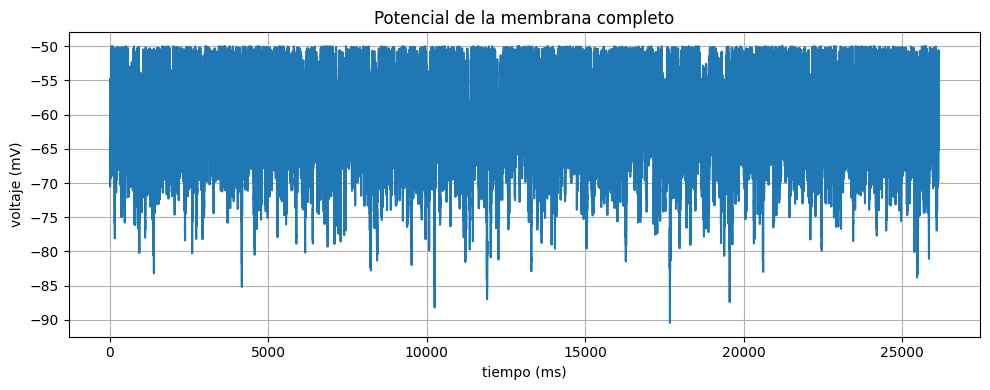

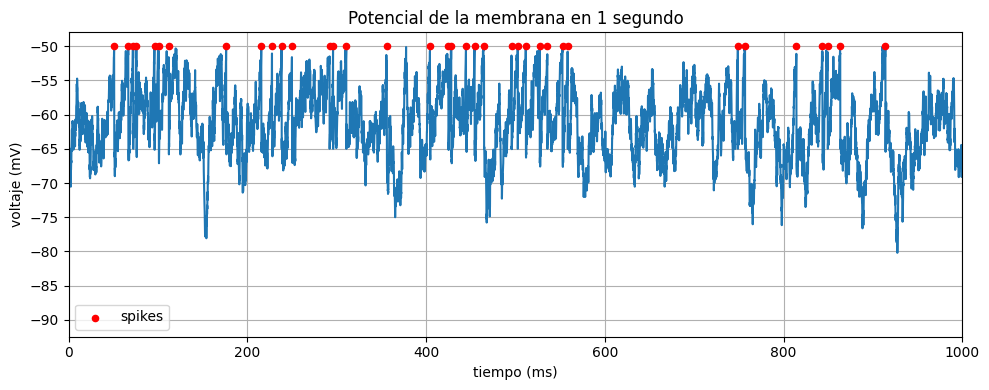

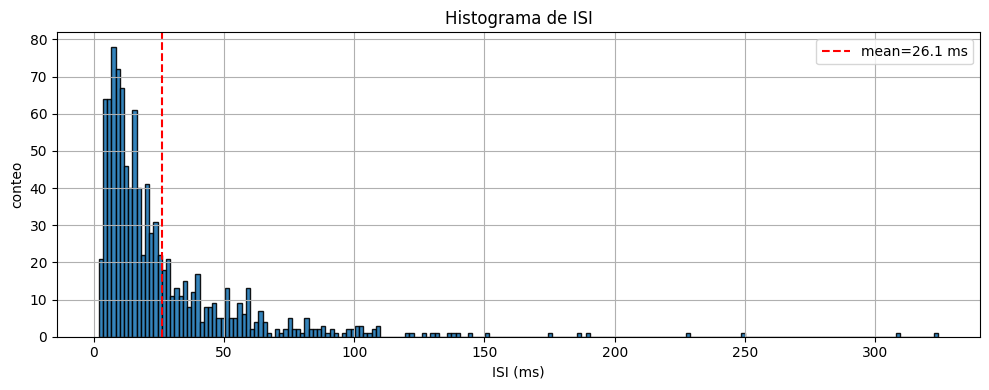

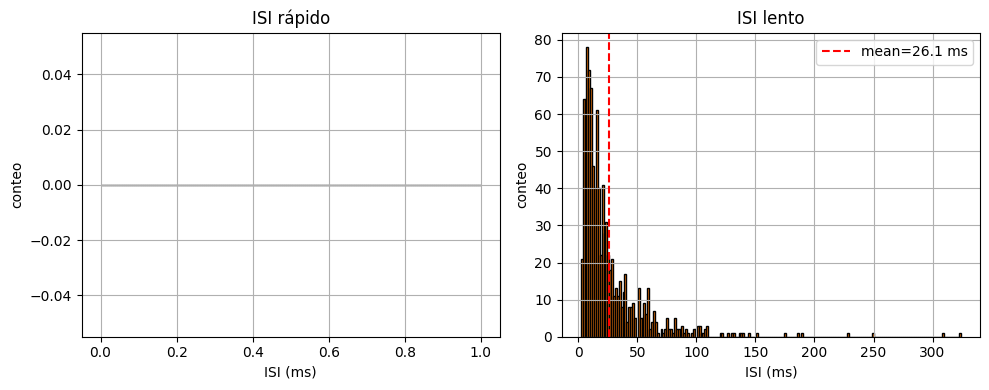

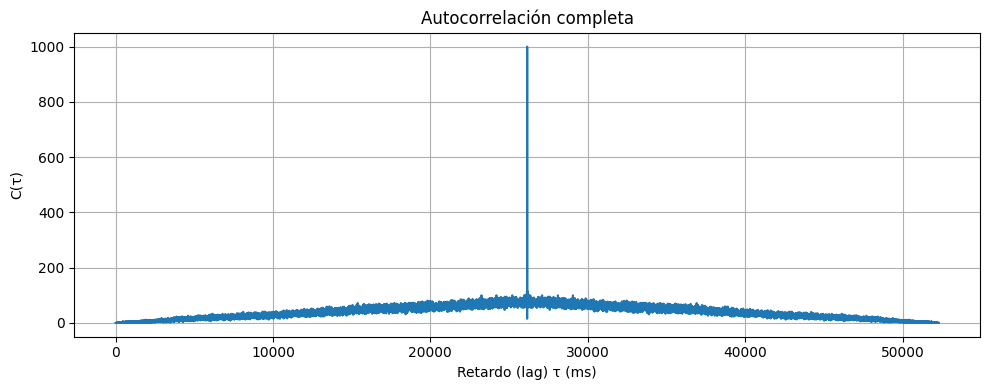

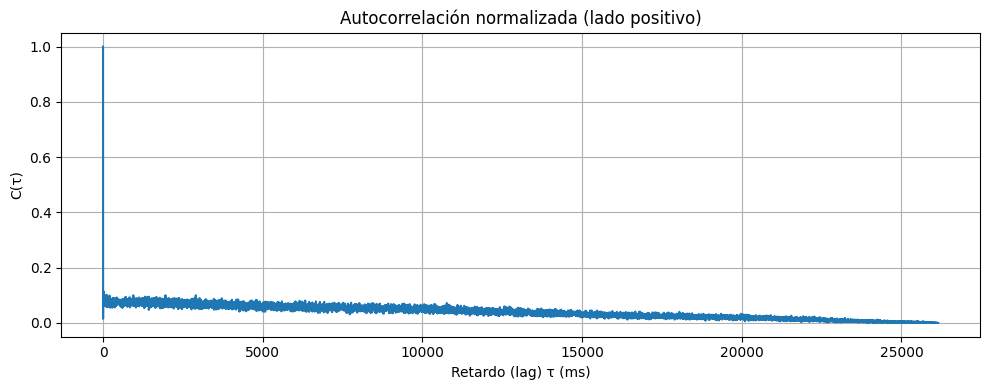

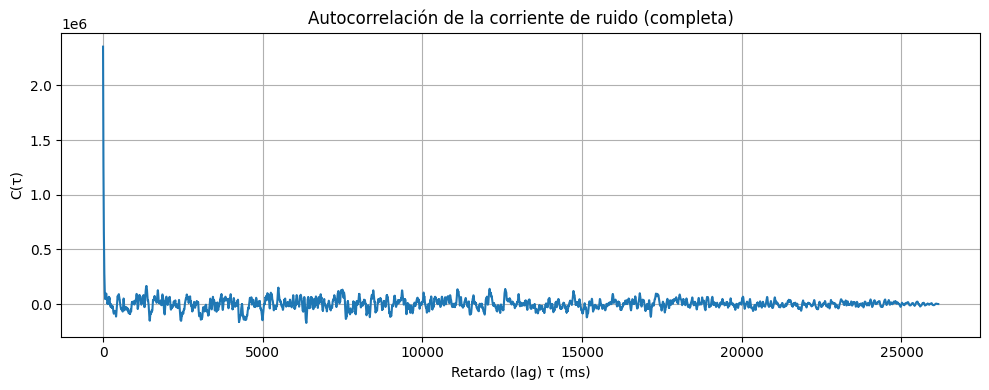

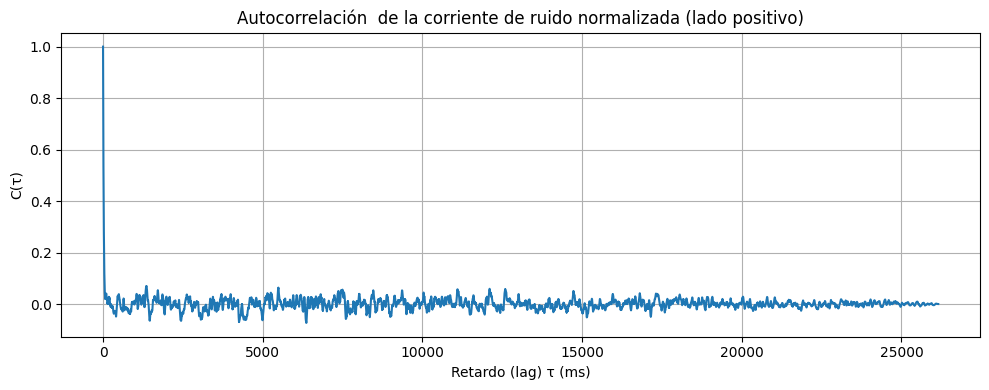

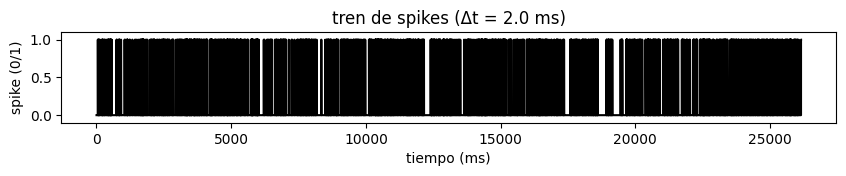

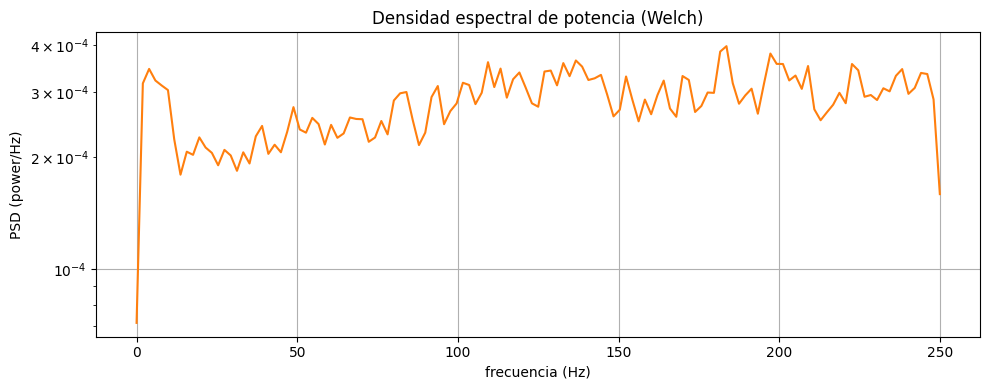

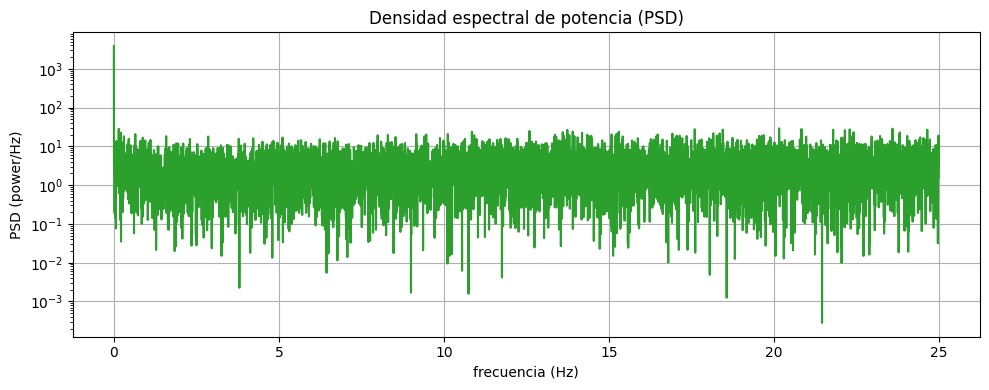

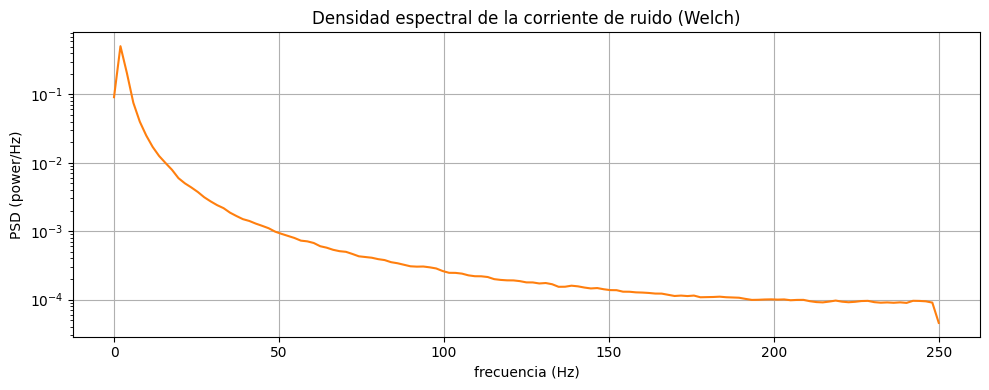

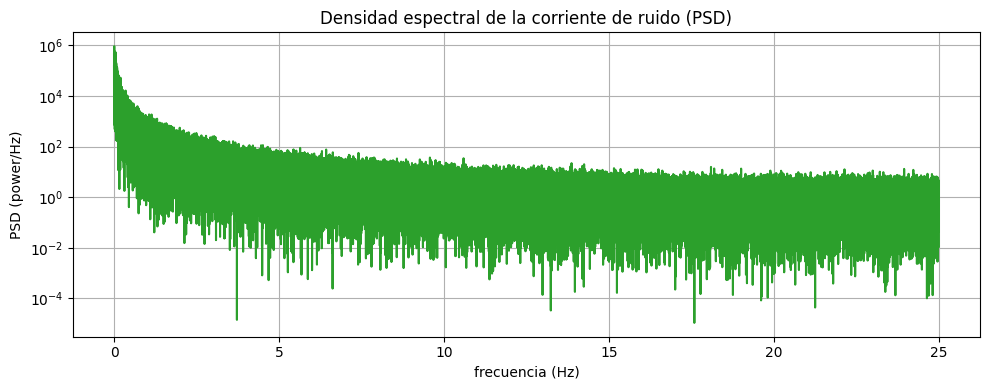

In [82]:
lif_noise(sigma=3)

## Comparación: Ruido blanco - vs - Ruido de color

### Función para comparar gráficas

In [83]:
def lif_comparative(sigma=1 # Amplitud del ruido
):
    # ---- Parámetros de la neurona LIF ----
    R = 1                  # Resistencia
    I_det = 10             # Corriente determinista
    V_rest = V_reset = -65 # Potencial de reposo y reset
    V_th = -50             # Umbral de disparo
    tau_m = 10             # Constante de tiempo de membrana (ms)
    dt = 0.1               # Paso de tiempo
    spikes_target = 1000   # Número de spikes a simular

    I_noise = 0.0          # Corriente de ruido
    tau_s = 20.0           # Constante de tiempo del ruido (ms)

    # ---- Solución con Euler - Maruyama ----

    V = V_reset
    t = 0

    voltages = []
    times = []
    spike_times = []

    while len(spike_times) < spikes_target:
        # Ruido blanco gaussiano
        dW = np.random.normal(0, np.sqrt(dt)) # Incremento de Wiener, Genera un valor aleatorio con media 0 y desviación estándar sqrt(dt)

        # Ecuación LIF con ruido (Euler-Maruyama)
        dV_dt = (-(V - V_rest) + R * I_det) / tau_m
        V += dV_dt * dt + sigma * dW

        if V >= V_th:
            spike_times.append(t)
            V = V_reset

        voltages.append(V)
        times.append(t)

        t += dt

    V = V_reset
    t = 0

    voltages_noise = []
    times_noise = []
    spike_times_noise = []
    noise_values = []

    while len(spike_times_noise) < spikes_target:
        # Ruido blanco gaussiano
        dW = np.random.normal(0, np.sqrt(dt)) # Incremento de Wiener, Genera un valor aleatorio con media 0 y desviación estándar sqrt(dt)
        I_noise += (-I_noise / tau_s) * dt + np.sqrt(2 * sigma**2 / tau_s) * dW
        noise_values.append(I_noise)

        # Ecuación LIF con ruido (Euler-Maruyama)
        I_total = I_det + I_noise
        dV_dt = (-(V - V_rest) + R * I_total) / tau_m
        V += dV_dt * dt + sigma * dW

        if V >= V_th:
            spike_times_noise.append(t)
            V = V_reset

        voltages_noise.append(V)
        times_noise.append(t)

        t += dt

    # ---- Gráficas del potencial de membrana ----

    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana completo (Ruido blanco)")
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(times_noise, voltages_noise)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana completo (Ruido de color)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(times, voltages)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana en 1 segundo (Ruido blanco)")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.scatter(spike_times, [V_th]*len(spike_times), color='r', s=20, zorder=3, label='spikes')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(times_noise, voltages_noise)
    plt.xlabel("tiempo (ms)")
    plt.ylabel("voltaje (mV)")
    plt.title("Potencial de la membrana en 1 segundo (Ruido de color)")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.scatter(spike_times_noise, [V_th]*len(spike_times_noise), color='r', s=20, zorder=3, label='spikes')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ---- Histogramas de ISI ----

    isis = np.diff(spike_times)
    bins = 200                # Número de barras para los histogramas
    isi_mean = np.mean(isis)
    burst_isi_thresh = 0.1    # Umbral para separar ISI rápidos y lentos (s)
    isi_fast = isis[isis < burst_isi_thresh]
    isi_low = isis[isis >= burst_isi_thresh]

    isis_noise = np.diff(spike_times_noise)
    isi_mean_noise = np.mean(isis_noise)
    isi_fast_noise = isis_noise[isis_noise < burst_isi_thresh]
    isi_low_noise = isis_noise[isis_noise >= burst_isi_thresh]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(isis, bins=bins, color='C0', edgecolor='k', alpha=0.9)
    plt.axvline(isi_mean, color='r', linestyle='--', label=f"mean={isi_mean:.1f} ms")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.title("Histograma de ISI (Ruido blanco)")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.hist(isis_noise, bins=bins, color='C0', edgecolor='k', alpha=0.9)
    plt.axvline(isi_mean_noise, color='r', linestyle='--', label=f"mean={isi_mean_noise:.1f} ms")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.title("Histograma de ISI (Ruido de color)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # --- histograma isi rápido ---
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(isi_fast, bins=bins, color='C0', edgecolor='k')
    if len(isi_fast) > 0:
        plt.axvline(np.mean(isi_fast), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_fast):.1f} ms")
    plt.title("ISI rápido (Ruido blanco)")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")

    plt.subplot(1,2,2)
    plt.hist(isi_fast_noise, bins=bins, color='C0', edgecolor='k')
    if len(isi_fast_noise) > 0:
        plt.axvline(np.mean(isi_fast_noise), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_fast_noise):.1f} ms")
    plt.title("ISI rápido (Ruido de color)")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # --- histograma isi lento ---
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(isi_low, bins=bins, color='C1', edgecolor='k')
    if len(isi_low) > 0:
        plt.axvline(np.mean(isi_low), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_low):.1f} ms")
    plt.title("ISI lento (Ruido blanco)")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()

    plt.subplot(1,2,2)
    plt.hist(isi_low_noise, bins=bins, color='C1', edgecolor='k')
    if len(isi_low_noise) > 0:
        plt.axvline(np.mean(isi_low_noise), color='r', linestyle='--',
                    label=f"mean={np.mean(isi_low_noise):.1f} ms")
    plt.title("ISI lento (Ruido de color)")
    plt.xlabel("ISI (ms)")
    plt.ylabel("conteo")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # --- Autocorrelación (ACF) ruido blanco ---
    dt_bin = 2.0  # ms (2.0 ms bins)
    duration = times[-1] - times[0]
    N_bins = int(np.ceil(duration / dt_bin))
    spike_train = np.zeros(N_bins)

    for spike_time in spike_times:
        bin_idx = int((spike_time - times[0])/ dt_bin)
        if 0 <= bin_idx < N_bins:
            spike_train[bin_idx] = 1

    correlate_complete = fftconvolve(spike_train, spike_train[::-1], mode='full') # fftconvolve es más eficiente
    correlate_positive = correlate_complete[len(correlate_complete)//2:]  # Tomar solo la mitad positiva
    correlate_positive = correlate_positive / correlate_positive[0] # Normalizar

    t_correlate_complete = np.arange(len(correlate_complete)) * dt_bin
    t_correlate_positive = np.arange(len(correlate_positive)) * dt_bin

    # --- Autocorrelación (ACF) ruido de color ---

    duration_noise = times_noise[-1] - times_noise[0]
    N_bins_noise = int(np.ceil(duration_noise / dt_bin))
    spike_train_noise = np.zeros(N_bins_noise)

    for spike_time in spike_times_noise:
        bin_idx = int((spike_time - times_noise[0])/ dt_bin)
        if 0 <= bin_idx < N_bins_noise:
            spike_train_noise[bin_idx] = 1

    correlate_complete_noise = fftconvolve(spike_train_noise, spike_train_noise[::-1], mode='full') # fftconvolve es más eficiente
    correlate_positive_noise = correlate_complete_noise[len(correlate_complete_noise)//2:]  # Tomar solo la mitad positiva
    correlate_positive_noise = correlate_positive_noise / correlate_positive_noise[0] # Normalizar

    t_correlate_complete_noise = np.arange(len(correlate_complete_noise)) * dt_bin
    t_correlate_positive_noise = np.arange(len(correlate_positive_noise)) * dt_bin

    # Función de autocorrelación completa
    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    plt.plot(t_correlate_complete, correlate_complete, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación completa (Ruido blanco)')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(t_correlate_complete_noise, correlate_complete_noise, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación completa (Ruido de color)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Función de autocorrelación positiva
    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    plt.plot(t_correlate_positive, correlate_positive, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación normalizada (Lado positivo - Ruido blanco)')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(t_correlate_positive_noise, correlate_positive_noise, color='C0')
    plt.xlabel('Retardo (lag) τ (ms)')
    plt.ylabel('C(τ)')
    plt.title('Autocorrelación normalizada (Lado positivo - Ruido de color)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # ---- Densidad espectral de potencia (welch) ----
    fs_bin = 1000.0 / dt_bin
    frequencies_welch, power_spectrum = welch(spike_train, fs=fs_bin, nperseg=min(256, len(spike_train)//4))
    frequencies_welch_noise, power_spectrum_noise = welch(spike_train_noise, fs=fs_bin, nperseg=min(256, len(spike_train_noise)//4))

    # Densidad espectral de potencia (Welch)
    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    plt.semilogy(frequencies_welch, power_spectrum, color='C1')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (Welch - Ruido blanco)')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.semilogy(frequencies_welch_noise, power_spectrum_noise, color='C1')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (Welch - Ruido de color)')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---- Densidad espectral de potencia (psd) ruido blanco ----
    fft_result = np.fft.rfft(spike_train)
    frequencies_psd = np.fft.rfftfreq(len(spike_train), d=0.02)
    psd = np.abs(fft_result)**2 / (len(spike_train) * 0.02)

    fft_result_noise = np.fft.rfft(spike_train_noise)
    frequencies_psd_noise = np.fft.rfftfreq(len(spike_train_noise), d=0.02)
    psd_noise = np.abs(fft_result_noise)**2 / (len(spike_train_noise) * 0.02)

    # Densidad espectral de potencia (PSD)
    plt.figure(figsize=(12, 5))

    plt.subplot(1,2,1)
    plt.semilogy(frequencies_psd, psd, color='C2')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (PSD - Ruido blanco)')
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.semilogy(frequencies_psd_noise, psd_noise, color='C2')
    plt.xlabel('frecuencia (Hz)')
    plt.ylabel('PSD (power/Hz)')
    plt.title('Densidad espectral de potencia (PSD - Ruido de color)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


### Sigma 1

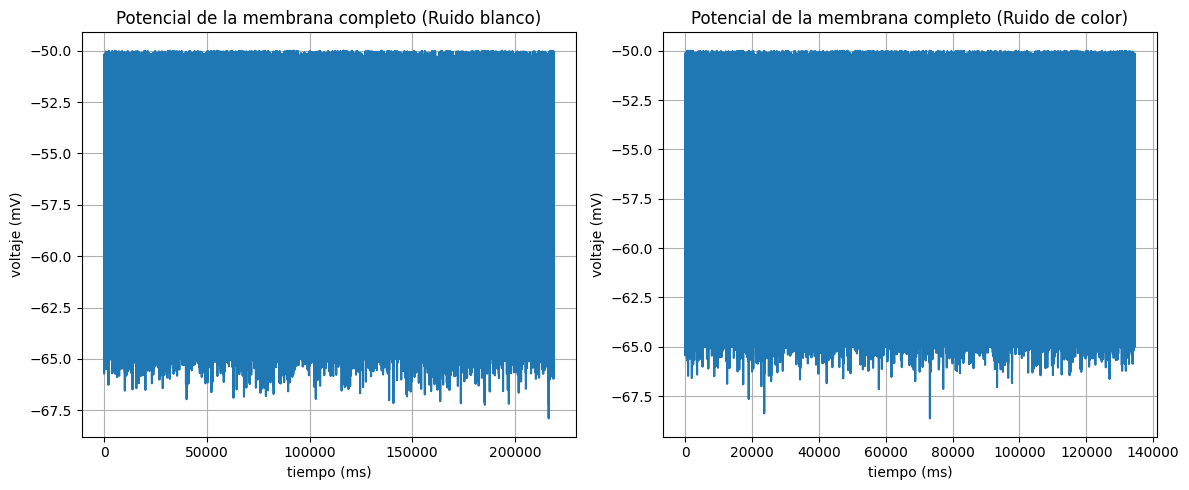

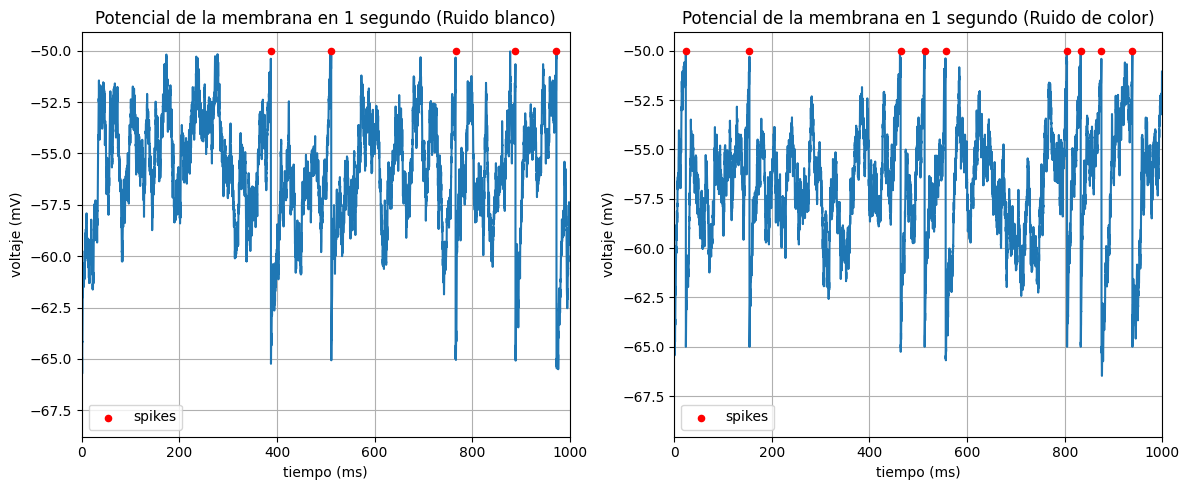

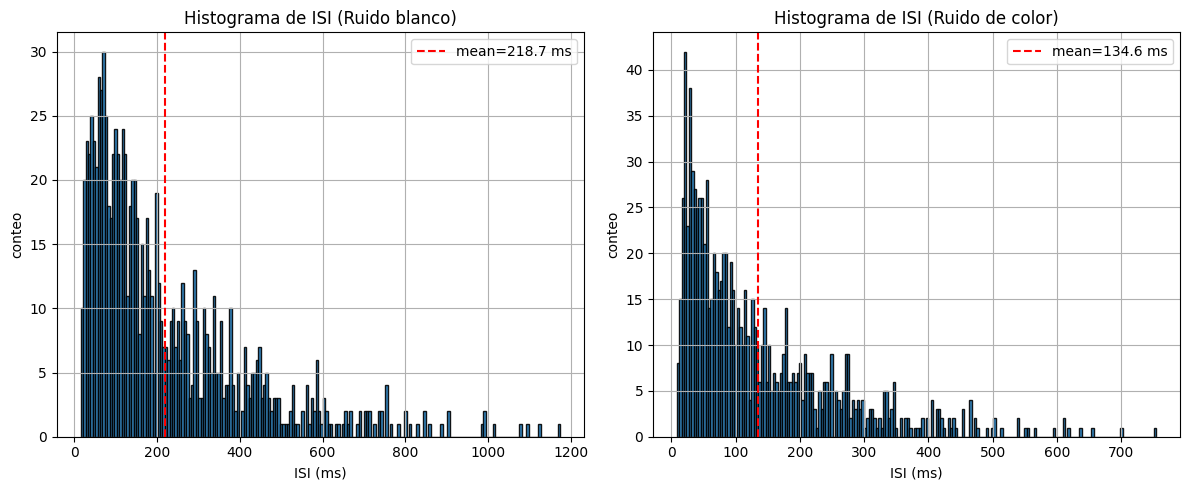

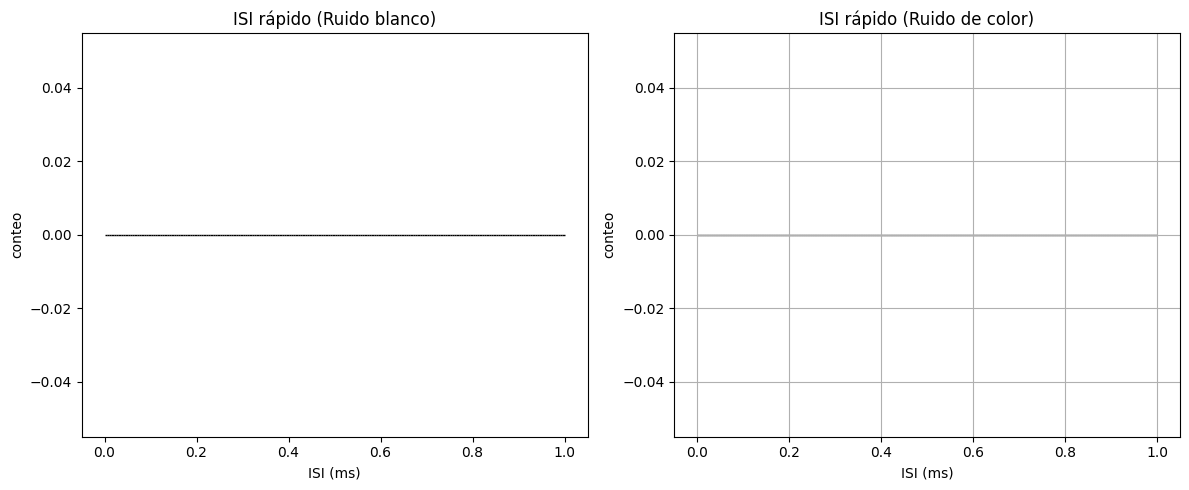

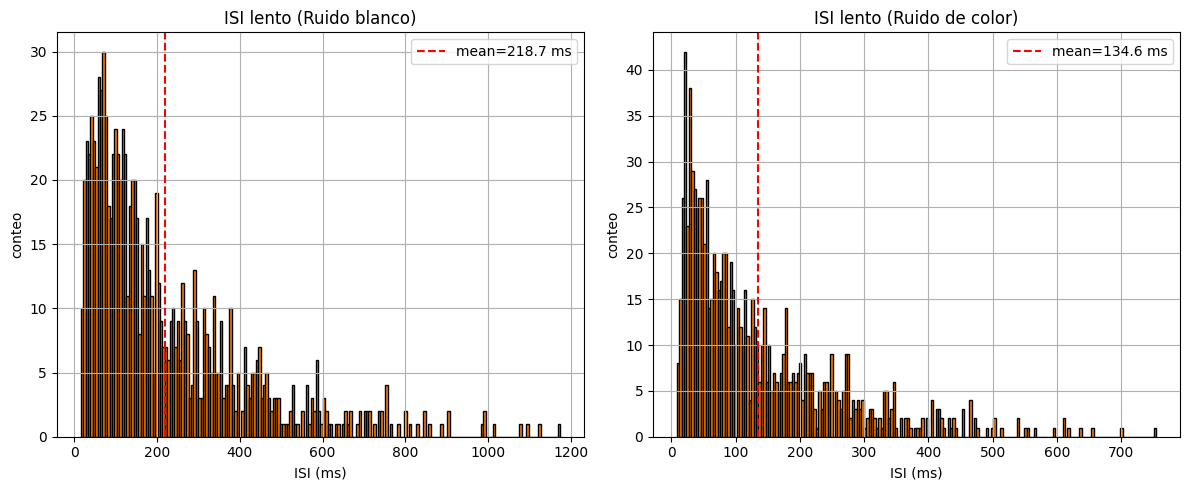

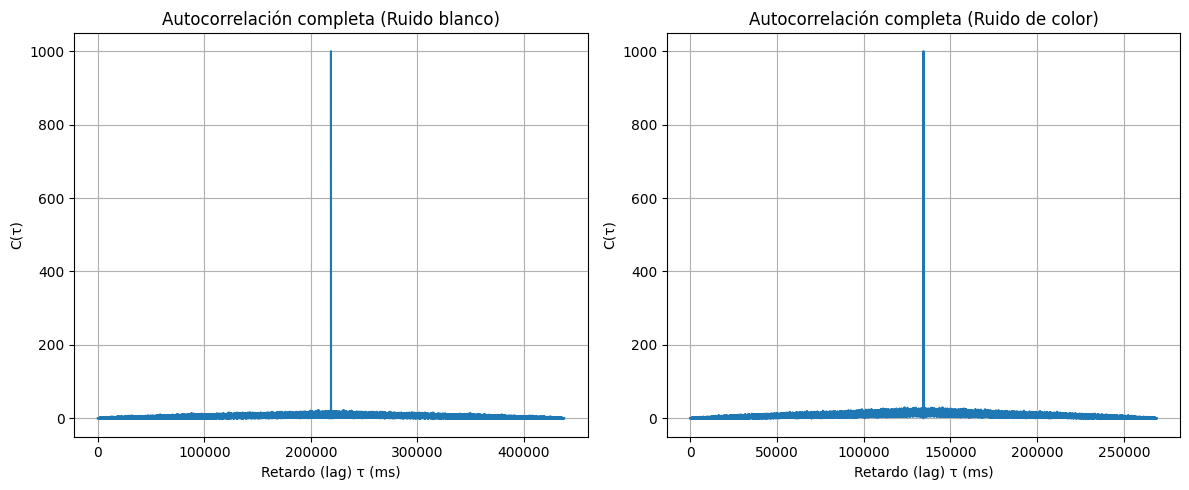

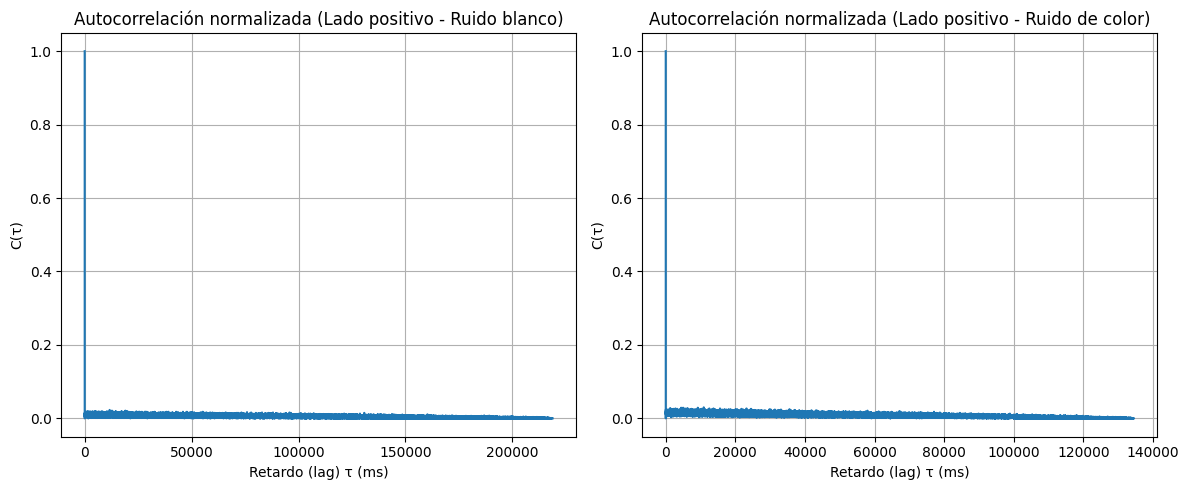

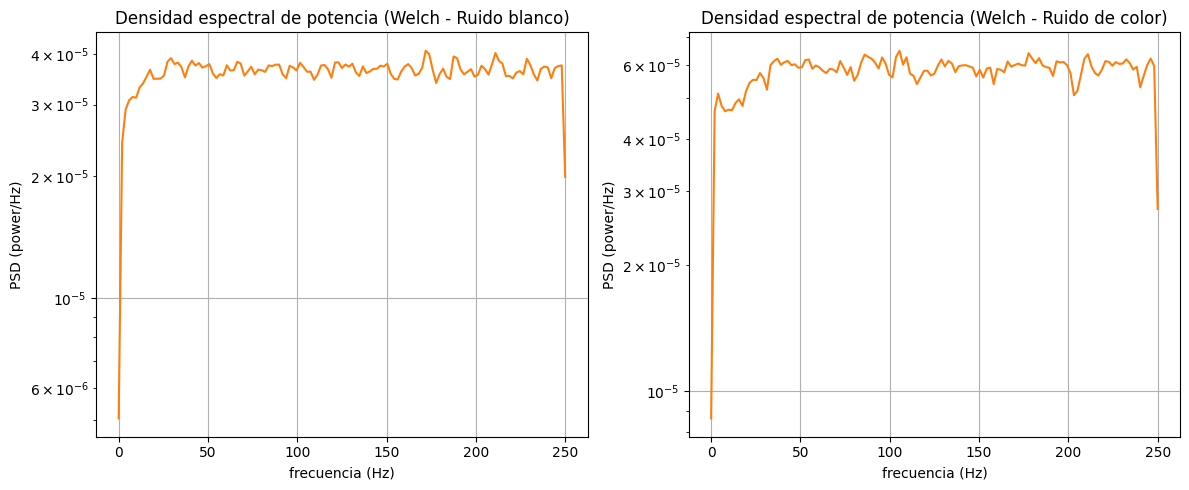

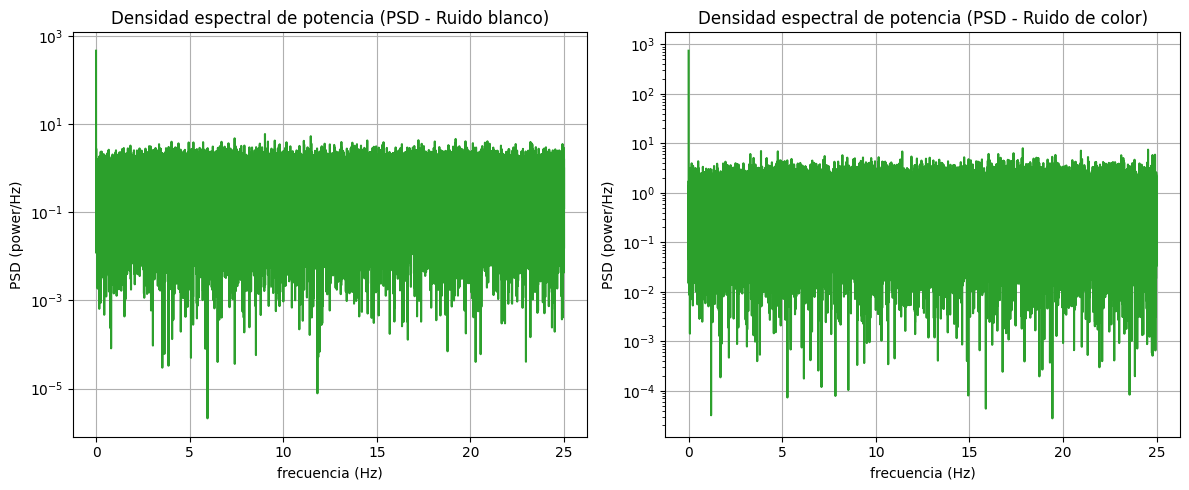

In [84]:
lif_comparative(sigma=1)

### Sigma 2

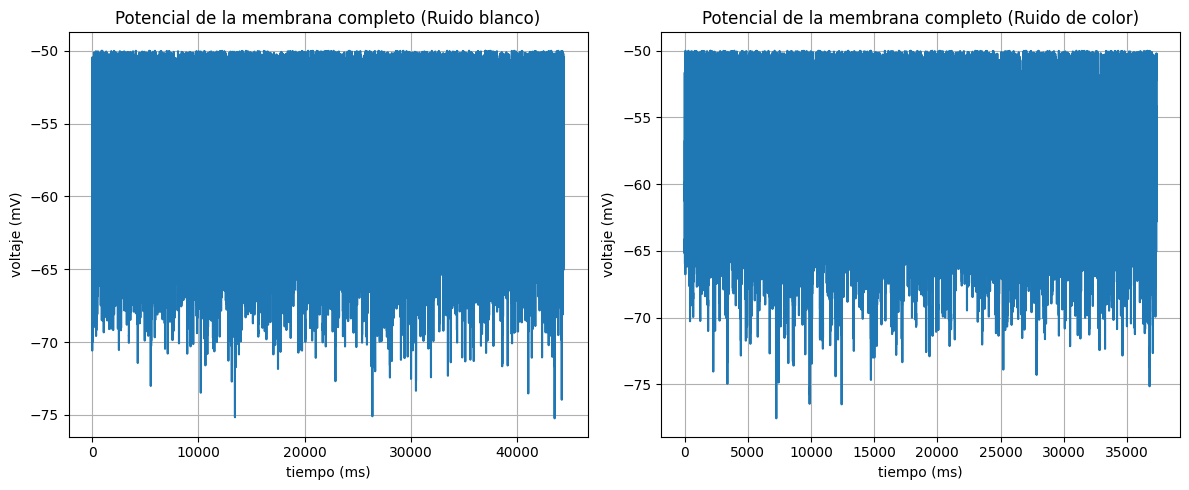

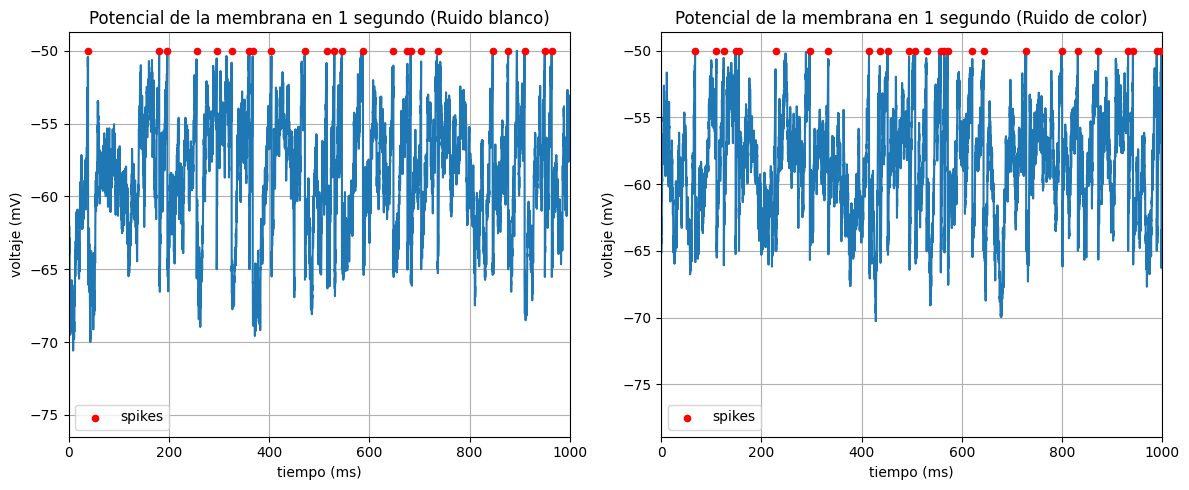

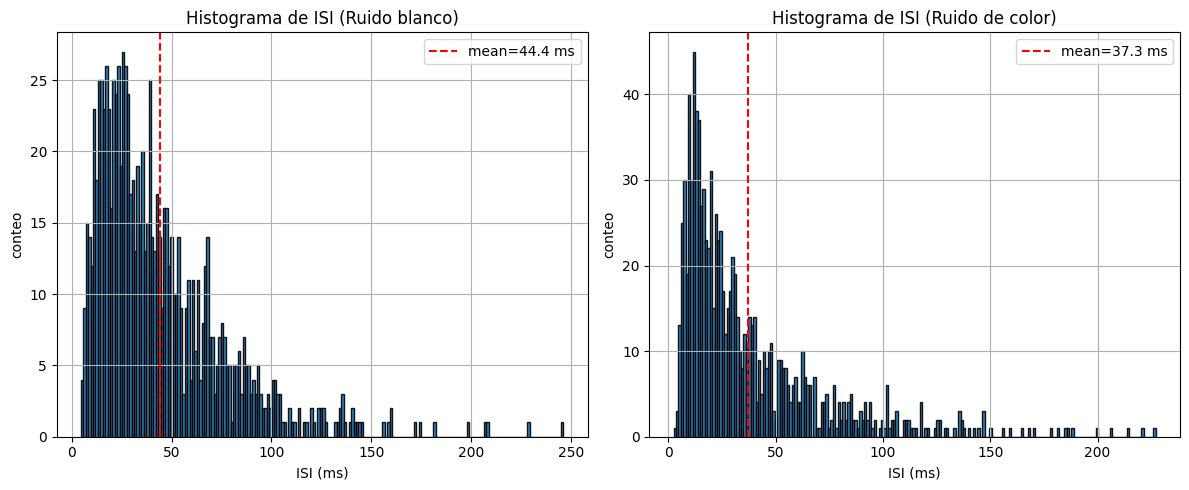

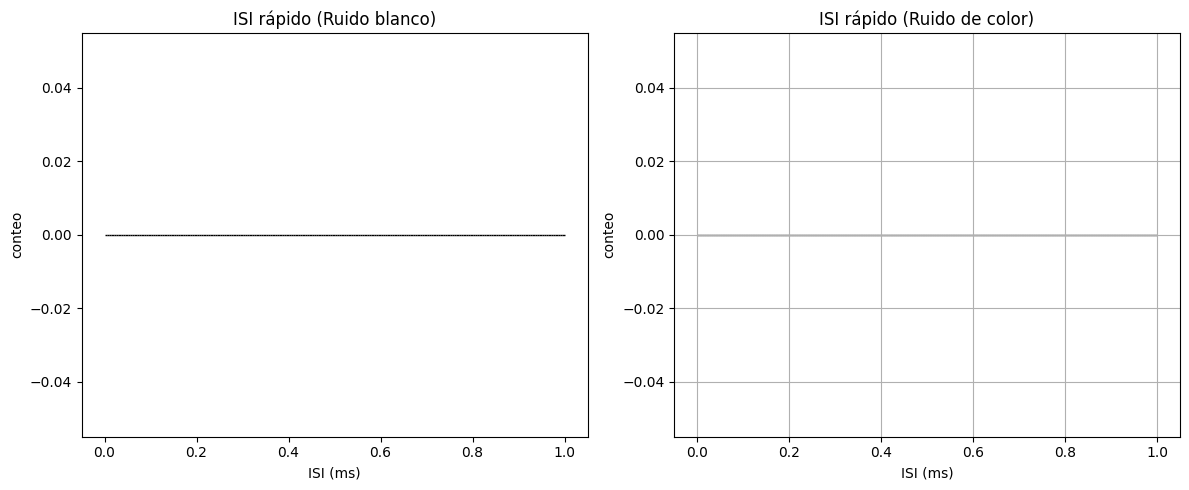

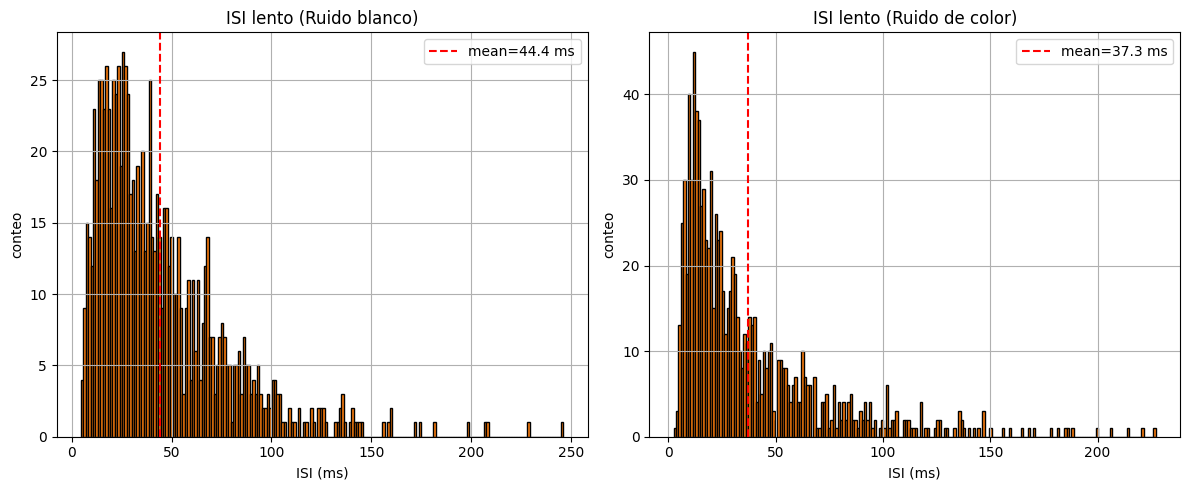

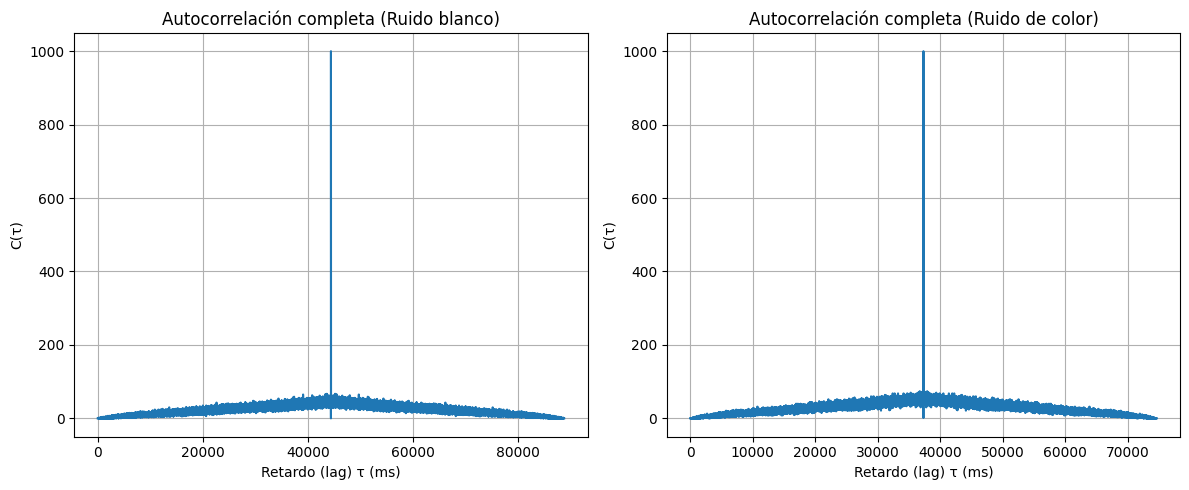

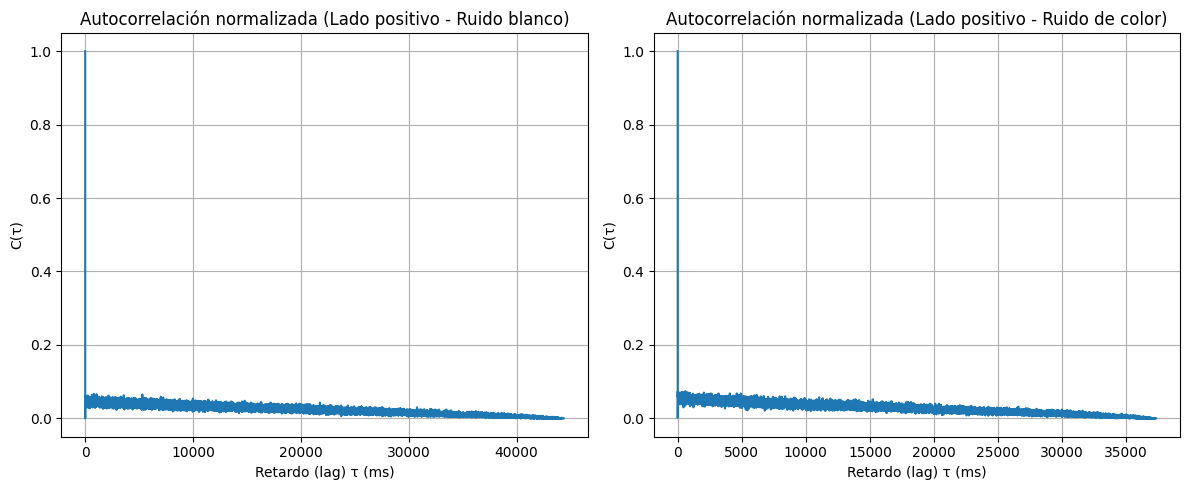

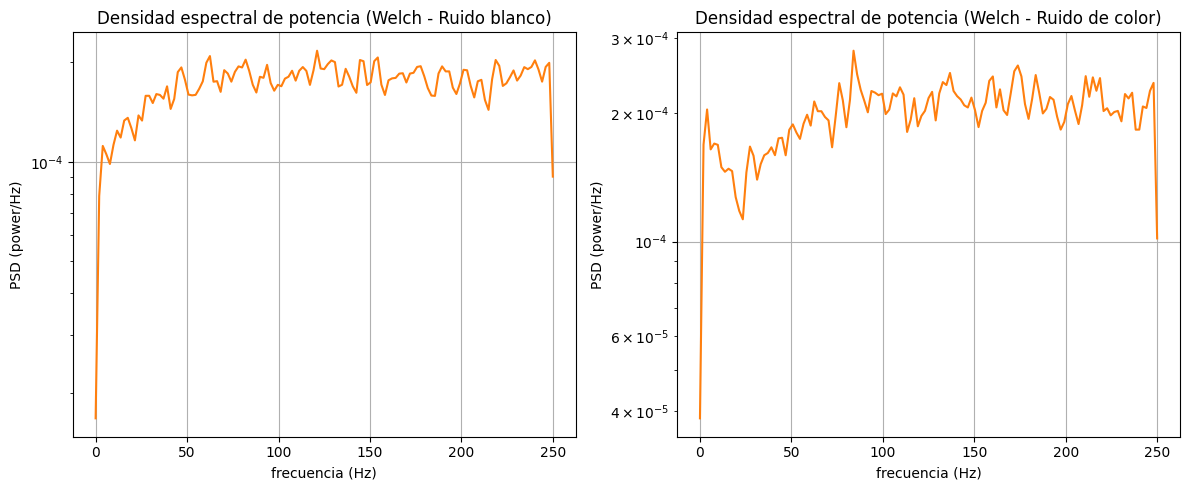

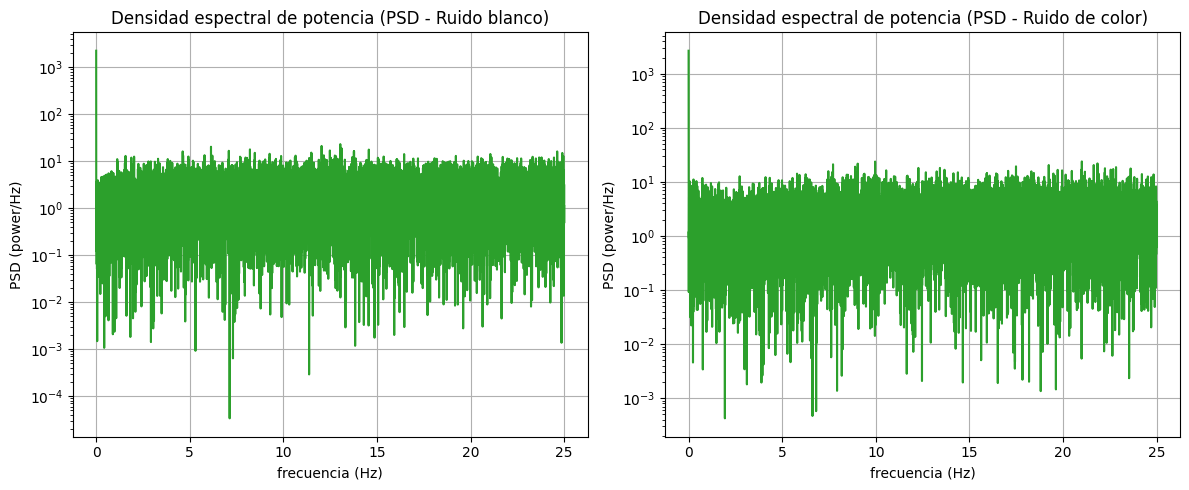

In [85]:
lif_comparative(sigma=2)

### Sigma 3

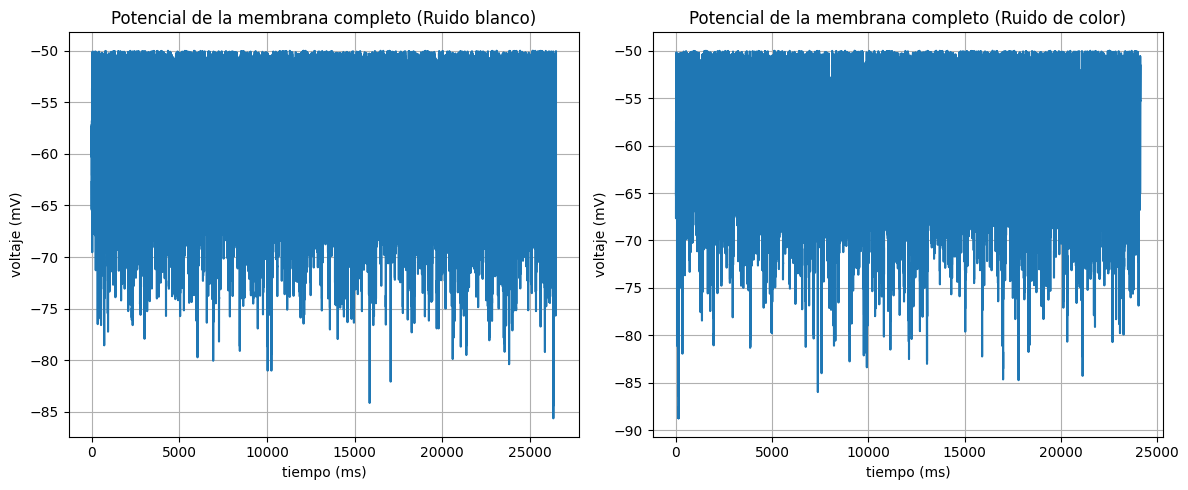

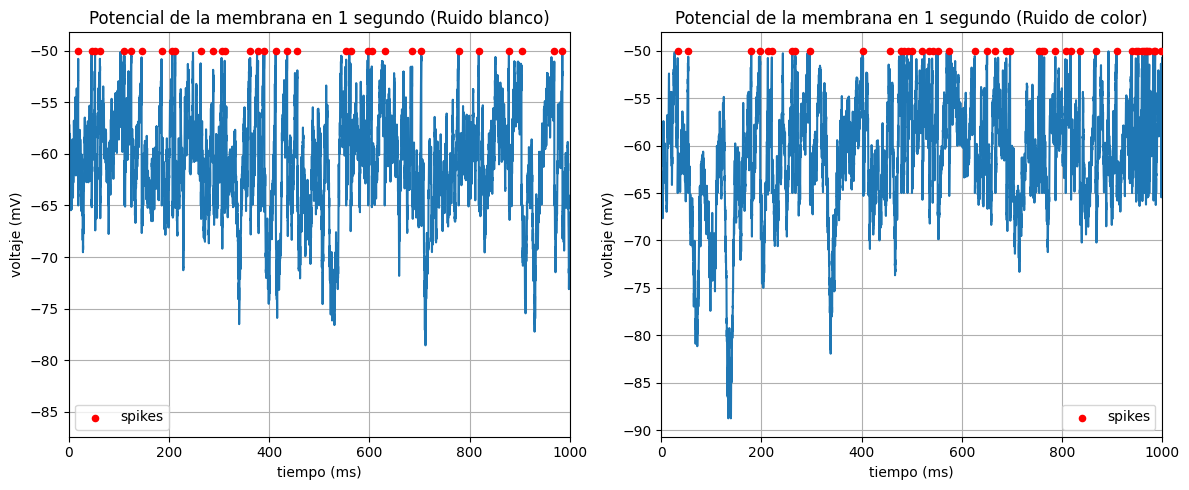

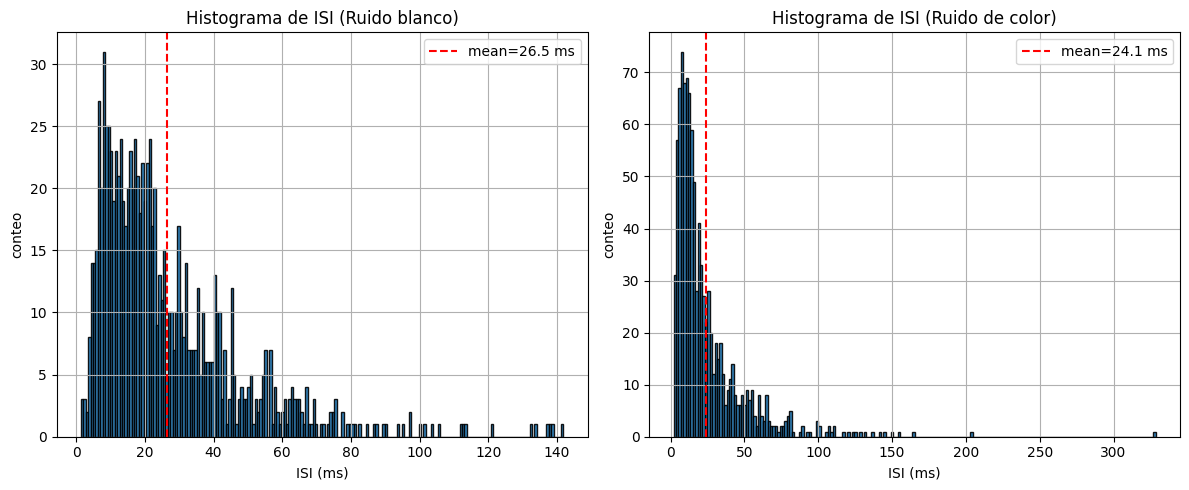

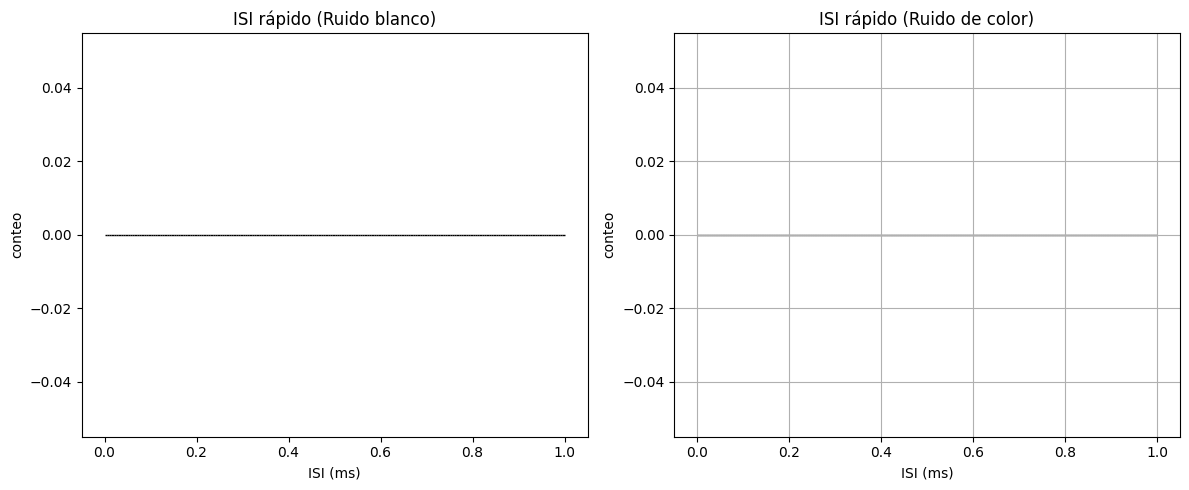

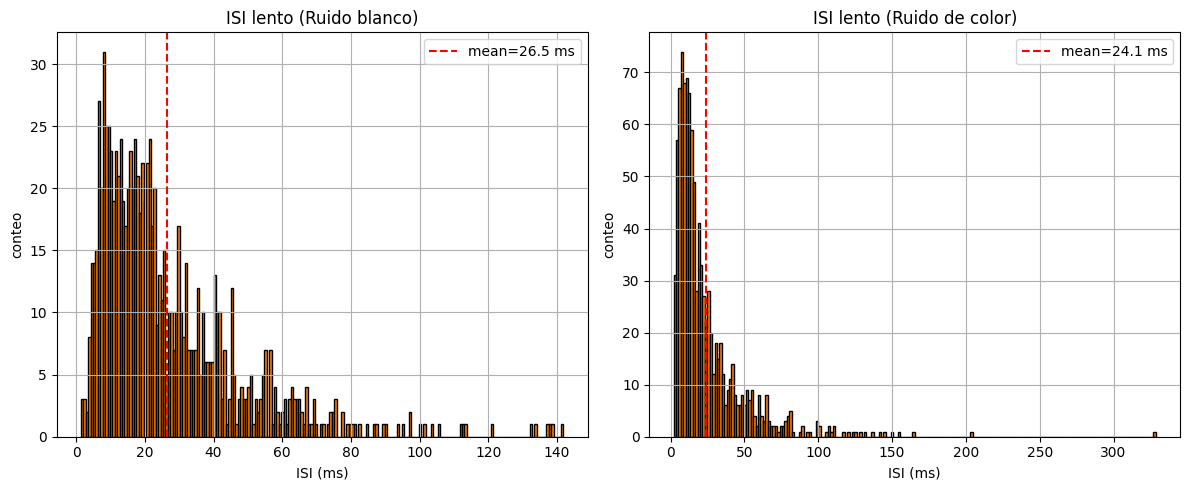

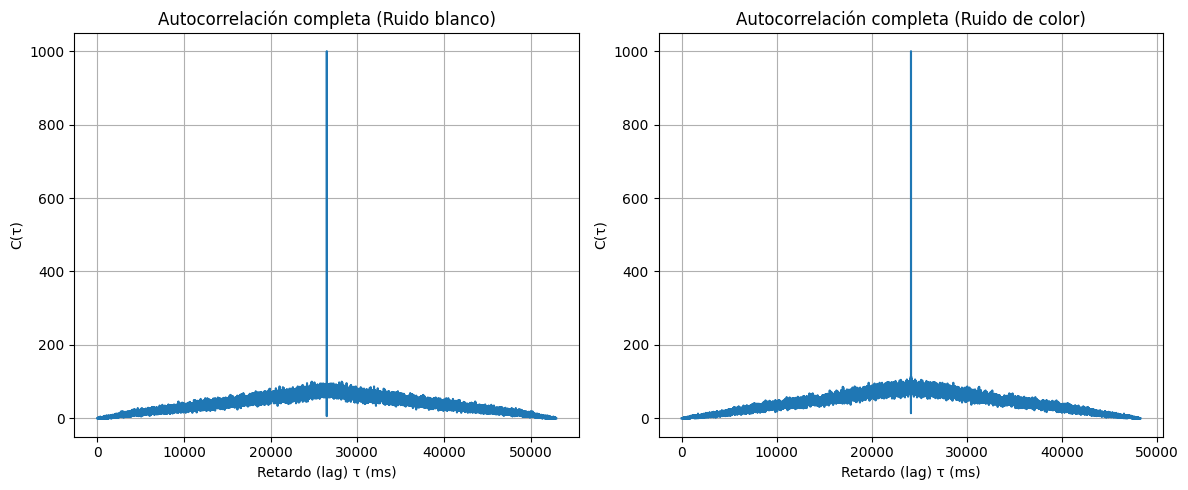

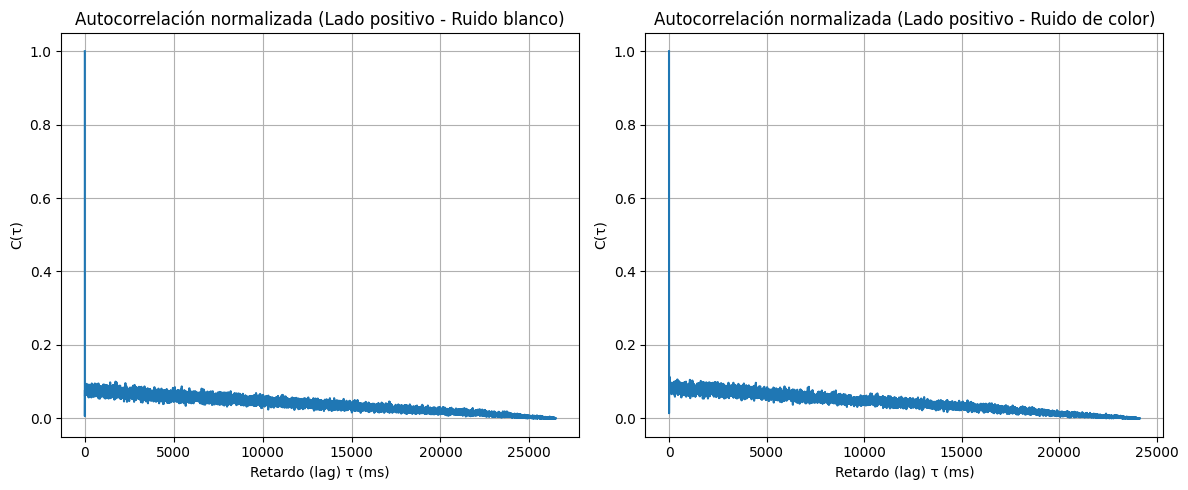

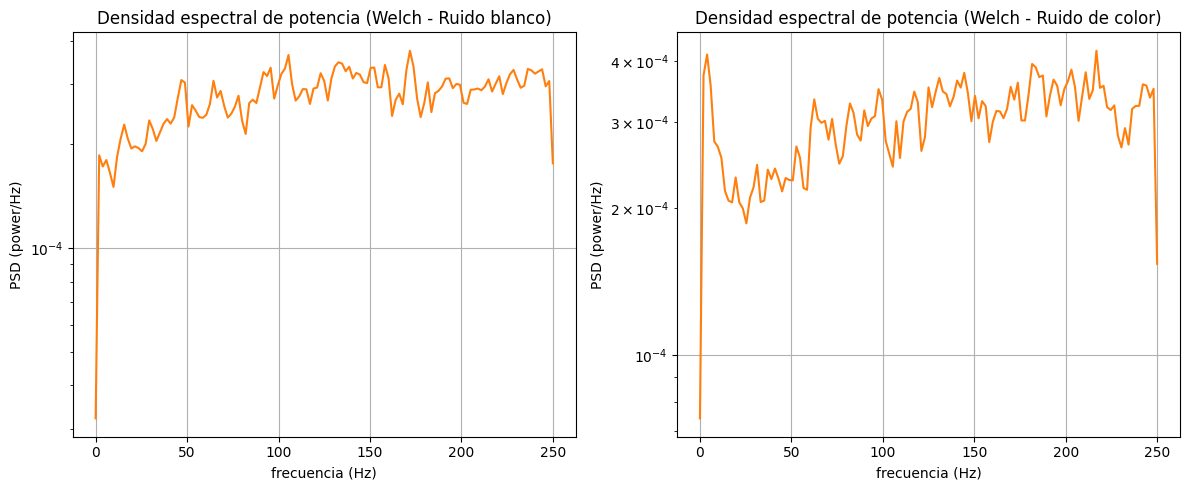

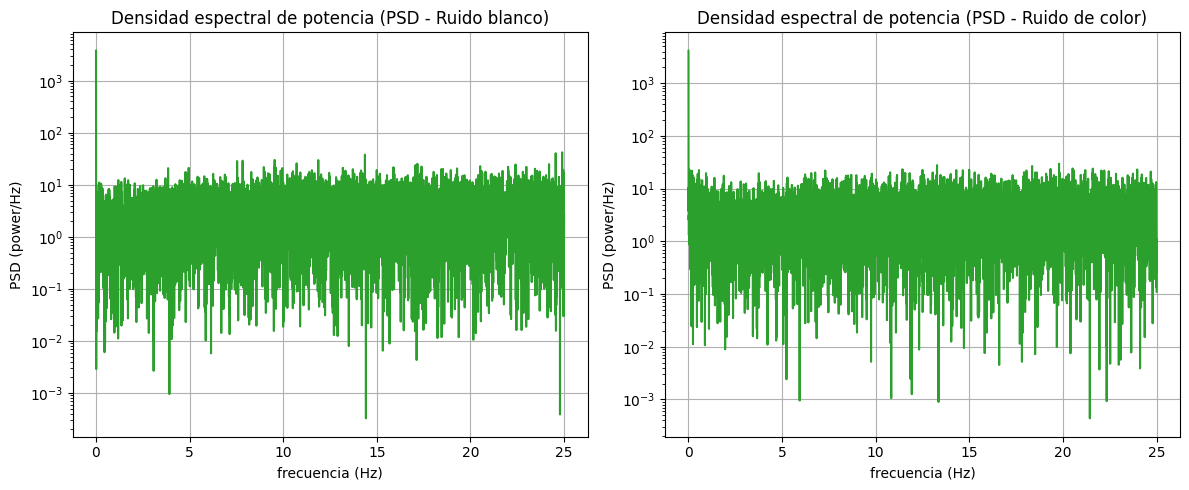

In [86]:
lif_comparative(sigma=3)

### Conclusiones de las gráficas:

- El ruido de color no varía tan bruscamente como el ruido blanco porque el ruido de color tiene dependencia en el tiempo (El valor de I_noise siguiente depende del anterior) lo que hace que la membrana genere spikes de manera más regular.

- El ruido de color tiende a mantener el potencial de la membrana en el umbral, lo que genera menor tiempo entre generar spikes, y genera trenes de spikes más seguido.

- El ruido blanco al no tener memoria (No tiene relación en el tiempo), su autocorrelación cae a 0 un poco más rápido en la mayoría de casos, según el sigma (Los valores dejan de depender del estado anterior con más facilidad)

- El ruido blanco, al ser más aleatorio, al generarse más fluctuaciones de subidas y bajadas en el potencial de la membrana, no mantiene el potencial en el umbral de acción, por lo que tiende a generar respuestas más irregulares.

### Conclusiones de realizar filtrados:

- El filtro de color introduce una correlación temporal (I_noise), lo que hace que el ruido cambie más lento (Ya no es totalmente independiente entre muestras como el ruido blanco). En consecuencia la membrana recibe una corriente suavizada, y los spikes tienden a tener más regularidad.

- Cuando filtramos ruido, modificamos la tasa de disparo (Puede aumentar o disminuir, dependiendo del filtro), la variabilidad del isis y la forma de distribución del isis.

- Por ejemploun filtro pasa bajas (de color) elimina componentes de alta frecuencia, lo que significa que hay menos cambios bruscos y la neurona se excita por tendencias más largas.